## Portable Dataset Setup and Execution Preconditions

This notebook is arranged so a collaborator can use **Run All** without manually uploading files into Kaggle. Public AIDev tables are downloaded from Hugging Face and cached locally. The CI-status parquet is loaded from, in order: an already attached Kaggle input folder, the public Kaggle dataset named in `CI_KAGGLE_DATASET`, or an optional direct URL in `CI_STATUS_URL`.

If the CI-status Kaggle dataset is private, make it public or set `CI_STATUS_URL` to a direct downloadable parquet URL before sharing the notebook. Cells are ordered to satisfy pipeline dependencies; sequential execution reproduces the analysis without manual reordering.

In [1]:
import os

# Point to your local files instead of HuggingFace
os.environ["DATA_DIR"] = r"C:\Users\rathn\Desktop\MSR2026_AIDEV-035B"
os.environ["CI_STATUS_URL"] = ""

print("Using local data from:", os.environ["DATA_DIR"])

Using local data from: C:\Users\rathn\Desktop\MSR2026_AIDEV-035B


In [2]:
%pip install -q tabulate statsmodels openpyxl huggingface_hub pyarrow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## One-Click Data Setup

Run this notebook from top to bottom. These helpers download and cache the required parquet files, so later cells do not depend on your personal `/kaggle/input/...` path.


In [3]:
from pathlib import Path
import os
import urllib.request

import pandas as pd

AIDEV_DATASET = "hao-li/AIDev"
CI_STATUS_FILENAME = "pr_ci_status_progress.parquet"
CI_STATUS_URL = os.getenv("CI_STATUS_URL", "").strip()

DEFAULT_DATA_DIR = "/kaggle/working/data" if Path("/kaggle/working").exists() else "data"
DATA_DIR = Path(os.getenv("DATA_DIR", DEFAULT_DATA_DIR))
DATA_DIR.mkdir(parents=True, exist_ok=True)


def load_aidev_table(table_name: str, refresh: bool = False) -> pd.DataFrame:
    """Load an AIDev parquet table from local cache or Hugging Face."""
    cache_path = DATA_DIR / f"{table_name}.parquet"
    if cache_path.exists() and not refresh:
        return pd.read_parquet(cache_path)

    source = f"hf://datasets/{AIDEV_DATASET}/{table_name}.parquet"
    print(f"Downloading {table_name}.parquet from Hugging Face...")
    df = pd.read_parquet(source)
    df.to_parquet(cache_path, index=False)
    return df


def _find_ci_status_file(search_root: Path) -> Path | None:
    if not search_root.exists():
        return None
    direct = search_root / CI_STATUS_FILENAME
    if direct.exists():
        return direct
    matches = list(search_root.rglob(CI_STATUS_FILENAME))
    return matches[0] if matches else None


def get_ci_status_path(refresh: bool = False) -> Path:
    """Return a local path to the CI-status parquet without requiring manual Kaggle upload."""
    cache_path = DATA_DIR / CI_STATUS_FILENAME
    if cache_path.exists() and not refresh:
        return cache_path

    for root in [Path("/kaggle/input"), Path(".")]:
        found = _find_ci_status_file(root)
        if found is not None:
            return found

    if CI_STATUS_URL:
        print(f"Downloading {CI_STATUS_FILENAME} from CI_STATUS_URL...")
        urllib.request.urlretrieve(CI_STATUS_URL, cache_path)
        return cache_path

    raise FileNotFoundError(
        f"Could not find {CI_STATUS_FILENAME}. Place it in the same folder as this notebook, "
        f"or set CI_STATUS_URL to a direct downloadable parquet URL."
    )


def load_ci_status(refresh: bool = False) -> pd.DataFrame:
    path = get_ci_status_path(refresh=refresh)
    print(f"Loading CI status from: {path}")
    return pd.read_parquet(path)


print(f"Data cache directory: {DATA_DIR.resolve()}")
print(f"AIDev source: hf://datasets/{AIDEV_DATASET}/")

Data cache directory: C:\Users\rathn\Desktop\MSR2026_AIDev-035B
AIDev source: hf://datasets/hao-li/AIDev/


In [4]:
from huggingface_hub import HfApi

api = HfApi()

print("Files on main:")
for f in api.list_repo_files("hao-li/AIDev", repo_type="dataset"):
    print(" ", f)

print("\nSearching commit history for pr_task_type.parquet...")
commits = api.list_repo_commits("hao-li/AIDev", repo_type="dataset")
for c in commits:
    files = api.list_repo_files("hao-li/AIDev", repo_type="dataset", revision=c.commit_id)
    if any("pr_task_type" in f for f in files):
        print(f"Found in commit {c.commit_id} ({c.created_at})")
        break
else:
    print("Not found in any commit history — table may have been renamed or dropped entirely.")

Files on main:
  .gitattributes
  AIDev_figure.png
  README.md
  aidev_logo.png
  all_pull_request.parquet
  all_repository.parquet
  all_user.parquet
  pr_comments.parquet
  pr_commit_details.parquet
  pr_commits.parquet
  pr_review_comments.parquet
  pr_reviews.parquet
  pull_request.parquet
  repository.parquet
  scripts/dataset_overview.py
  scripts/language_usage.py
  scripts/load_aidev.py
  scripts/productivity.py
  user.parquet

Searching commit history for pr_task_type.parquet...
Found in commit 68ed5f4b80d27a9e057fc57567f38bd322ac73ec (2026-05-10 18:01:13+00:00)


In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

from pathlib import Path

pull_request_path = None
for root in [Path("/kaggle/input"), Path(".")]:
    if root.exists():
        matches = list(root.rglob("pull_request.parquet"))
        if matches:
            pull_request_path = matches[0]
            break

if pull_request_path is None:
    raise FileNotFoundError(
        "pull_request.parquet not found under /kaggle/input. "
        "Attach it as a Kaggle Input dataset first."
    )

pull_requests = pd.read_parquet(pull_request_path)

task_type_path = None
for root in [Path("/kaggle/input"), Path(".")]:
    if root.exists():
        matches = list(root.rglob("pr_task_type.parquet"))
        if matches:
            task_type_path = matches[0]
            break

if task_type_path is None:
    raise FileNotFoundError(
        "pr_task_type.parquet not found under /kaggle/input. "
        "Attach it as a Kaggle Input dataset first."
    )

print(f"Loading pr_task_type from: {task_type_path}")
pr_task_type = pd.read_parquet(task_type_path)

ai_agents = set(pull_requests['agent'].dropna().str.lower().unique()) | \
             set(pr_task_type['agent'].dropna().str.lower().unique())

print(f"Total unique AI agents in AIDev dataset: {len(ai_agents)}")
print(f"Agents list: {sorted(list(ai_agents))}")


Loading pr_task_type from: pr_task_type.parquet
Total unique AI agents in AIDev dataset: 5
Agents list: ['claude_code', 'copilot', 'cursor', 'devin', 'openai_codex']


In [6]:
import pandas as pd
from IPython.display import display

from pathlib import Path

pull_request_path = None
for root in [Path("/kaggle/input"), Path(".")]:
    if root.exists():
        matches = list(root.rglob("pull_request.parquet"))
        if matches:
            pull_request_path = matches[0]
            break

if pull_request_path is None:
    raise FileNotFoundError(
        "pull_request.parquet not found under /kaggle/input. "
        "Attach it as a Kaggle Input dataset first."
    )

pull_requests = pd.read_parquet(pull_request_path)
print("Total PRs in pull_request table:", len(pull_requests))

pull_requests["agent"] = pull_requests["agent"].astype(str).str.lower()

ai_agents = sorted(pull_requests["agent"].dropna().unique().tolist())
print(f"Found {len(ai_agents)} AI agents: {ai_agents}\n")

def classify_pr(row):
    if pd.notna(row["merged_at"]):  # merged_at has a timestamp
        if row["state"] == "closed":
            return "Merged+Closed PR's"
        elif row["state"] == "open":
            return "Merged+Open PR's"
        else:
            return "Merged+Other"
    else:  # not merged
        if row["state"] == "closed":
            return "Not-merged+Closed PR's"
        elif row["state"] == "open":
            return "Not-merged+Open PR's"
        else:
            return "Not-merged+Other"

pull_requests["merge_status"] = pull_requests.apply(classify_pr, axis=1)

ai_prs = pull_requests[pull_requests["agent"].isin(ai_agents)]

summary = (
    ai_prs.groupby(["agent", "merge_status"])
    .size()
    .reset_index(name="count")
    .pivot(index="agent", columns="merge_status", values="count")
    .fillna(0)
    .astype(int)
    .reset_index()
)


summary.index.name = None
summary.columns.name = None

desired_cols = [
    "agent",
    "Merged+Closed PR's",
    "Merged+Open PR's",
    "Not-merged+Closed PR's",
    "Not-merged+Open PR's",
]
summary = summary.reindex(columns=[c for c in desired_cols if c in summary.columns])

overall = summary.drop(columns=["agent"]).sum().to_frame().T
overall.insert(0, "agent", "Overall")
summary = pd.concat([summary, overall], ignore_index=True)

display(summary.style.hide(axis="index"))


Total PRs in pull_request table: 33596
Found 5 AI agents: ['claude_code', 'copilot', 'cursor', 'devin', 'openai_codex']



agent,Merged+Closed PR's,Not-merged+Closed PR's,Not-merged+Open PR's
claude_code,271,109,79
copilot,2139,1752,1079
cursor,1005,342,194
devin,2595,2078,154
openai_codex,18004,2989,806
Overall,24014,7270,2312


In [7]:
# import pandas as pd
# from IPython.display import display

# pull_requests = load_aidev_table("pull_request")
pr_commit_details = load_aidev_table("pr_commit_details")

print("Total PRs in pull_request table:", len(pull_requests))
print("Unique PRs with commit details:", pr_commit_details["pr_id"].nunique())

pull_requests["agent"] = pull_requests["agent"].astype(str).str.lower()
ai_agents = sorted(pull_requests["agent"].dropna().unique().tolist())
print(f"Found {len(ai_agents)} AI agents: {ai_agents}\n")

pull_requests["merge_status"] = pull_requests["merged_at"].notna().map({True: "Merged", False: "Not-Merged"})

pr_stats = (
    pr_commit_details.groupby("pr_id")
    .agg(
        num_files_changed=("filename", "nunique"),
        total_changes=("changes", "sum")
    )
    .reset_index()
)

pull_requests = pull_requests.merge(pr_stats, left_on="id", right_on="pr_id", how="left")

pull_requests["num_files_changed"] = pull_requests["num_files_changed"].fillna(0)
pull_requests["total_changes"] = pull_requests["total_changes"].fillna(0)

ai_data = pull_requests[pull_requests["agent"].isin(ai_agents)].copy()

metrics = (
    ai_data.groupby(["agent", "merge_status"])
    .agg(
        avg_lines_changed=("total_changes", "mean"),
        avg_files_touched=("num_files_changed", "mean"),
        num_prs=("id", "count")
    )
    .reset_index()
    .round(2)
)

merged_table = metrics[metrics["merge_status"] == "Merged"].drop(columns="merge_status")
not_merged_table = metrics[metrics["merge_status"] == "Not-Merged"].drop(columns="merge_status")

merged_overall = merged_table.drop(columns=["agent"]).mean(numeric_only=True).to_frame().T
merged_overall["num_prs"] = merged_table["num_prs"].sum()
merged_overall.insert(0, "agent", "Overall")
merged_table = pd.concat([merged_table, merged_overall], ignore_index=True)

not_merged_overall = not_merged_table.drop(columns=["agent"]).mean(numeric_only=True).to_frame().T
not_merged_overall["num_prs"] = not_merged_table["num_prs"].sum()
not_merged_overall.insert(0, "agent", "Overall")
not_merged_table = pd.concat([not_merged_table, not_merged_overall], ignore_index=True)

def display_table(df, title):
    df_disp = df.rename(columns={
        "agent": "AI Agent",
        "avg_lines_changed": "Avg. # Lines Changed",
        "avg_files_touched": "Avg. # Files Touched",
        "num_prs": "Total PRs"
    })
    print(f"\n{title}:")
    display(df_disp.style.format({
        "Avg. # Lines Changed": "{:.2f}",
        "Avg. # Files Touched": "{:.2f}"
    }).hide(axis="index"))

display_table(merged_table, "Merged PRs Summary per Agent")
display_table(not_merged_table, "Not-Merged PRs Summary per Agent")


Total PRs in pull_request table: 33596
Unique PRs with commit details: 71585
Found 5 AI agents: ['claude_code', 'copilot', 'cursor', 'devin', 'openai_codex']


Merged PRs Summary per Agent:


AI Agent,Avg. # Lines Changed,Avg. # Files Touched,Total PRs
claude_code,6715.01,23.66,271
copilot,5824.48,30.39,2139
cursor,2176.50,15.15,1005
devin,2892.37,27.11,2595
openai_codex,658.72,11.38,18004
Overall,3653.42,21.54,24014



Not-Merged PRs Summary per Agent:


AI Agent,Avg. # Lines Changed,Avg. # Files Touched,Total PRs
claude_code,14158.27,55.06,188
copilot,5842.33,30.61,2831
cursor,3945.82,23.50,536
devin,2398.48,25.48,2232
openai_codex,1645.82,18.44,3795
Overall,5598.14,30.62,9582


## Median-Split Outlier Analysis

Partitions PRs at the sample median of lines changed and files touched, isolating cases where merge outcome diverges from the dominant size–rejection trend — large PRs that merged, and small PRs that were rejected — for manual review.

In [8]:
import numpy as np

# --- Step 1: Compute medians ---
median_lines = pull_requests["total_changes"].median()
median_files = pull_requests["num_files_changed"].median()
print(f"Median lines changed: {median_lines}")
print(f"Median files touched: {median_files}")

# --- Step 2: Label every PR as small or large (using lines changed as the primary metric) ---
pull_requests["size_category"] = np.where(
    (pull_requests["total_changes"] > median_lines) | (pull_requests["num_files_changed"] > median_files),
    "Large", "Small"
)

# --- Step 3: Pull the two counterexample groups ---
large_but_merged = pull_requests[
    (pull_requests["size_category"] == "Large") &
    (pull_requests["merge_status"] == "Merged")
].copy()

small_but_rejected = pull_requests[
    (pull_requests["size_category"] == "Small") &
    (pull_requests["merge_status"] == "Not-Merged")
].copy()

print(f"\nLarge PRs that were still merged: {len(large_but_merged)}")
print(f"Small PRs that were still rejected: {len(small_but_rejected)}")

# --- Step 4: Randomly sample 50 from each (fixed seed for reproducibility) ---
sample_large_merged = large_but_merged.sample(n=min(50, len(large_but_merged)), random_state=42)
sample_small_rejected = small_but_rejected.sample(n=min(50, len(small_but_rejected)), random_state=42)

sample_large_merged["group"] = "Large but Merged"
sample_small_rejected["group"] = "Small but Rejected"

outlier_sample = pd.concat([sample_large_merged, sample_small_rejected], ignore_index=True)

# --- Step 5: Extract a readable repository name from repo_url ---
outlier_sample["repository"] = outlier_sample["repo_url"].str.extract(r"repos/([^/]+/[^/]+)")

# --- Step 6: Keep the columns useful for manual reading, add the three manual coding columns ---
outlier_sample = outlier_sample[[
    "id", "number", "title", "body", "agent", "repository", "html_url",
    "total_changes", "num_files_changed", "merge_status", "group"
]].copy()

outlier_sample["change_type"] = ""              # fill in while reading — see Codebook sheet
outlier_sample["accept_reject_reason"] = ""      # fill in while reading — see Codebook sheet
outlier_sample["observation"] = ""               # free text notes

outlier_sample.to_csv("outlier_sample_for_manual_review.csv", index=False)

# --- Step 7: Export Excel with a Codebook reference sheet, matching the taxonomy coding sheet's structure ---
import pandas as pd

CHANGE_TYPES = ["Bug Fix", "New Feature", "Refactoring", "Documentation", "Tests",
                "Dependency Update", "Configuration", "CI/CD", "Performance", "Security", "Other"]
ACCEPT_REASONS = ["Valuable feature", "Maintainer requested", "Critical bug", "Good implementation", "Project aligned"]
REJECT_REASONS = ["Scope too large", "Maintainer not interested", "Duplicate", "CI failure",
                   "Wrong implementation", "Style issue", "Missing tests", "Reviewer abandoned"]

max_len = max(len(CHANGE_TYPES), len(ACCEPT_REASONS), len(REJECT_REASONS))
change_types_padded = CHANGE_TYPES + [""] * (max_len - len(CHANGE_TYPES))
accept_padded = ACCEPT_REASONS + [""] * (max_len - len(ACCEPT_REASONS))
reject_padded = REJECT_REASONS + [""] * (max_len - len(REJECT_REASONS))

codebook = pd.DataFrame({
    "Change Type (examples)": change_types_padded,
    "Acceptance Reasons (examples)": accept_padded,
    "Rejection Reasons (examples)": reject_padded,
})

with pd.ExcelWriter("outlier_sample_for_manual_review.xlsx", engine="openpyxl") as writer:
    outlier_sample.to_excel(writer, index=False, sheet_name="PR Sample")
    codebook.to_excel(writer, index=False, sheet_name="Codebook")

print(f"\nSaved {len(outlier_sample)} PRs to outlier_sample_for_manual_review.csv")
print("Saved outlier_sample_for_manual_review.xlsx (PR Sample + Codebook sheets)")
outlier_sample.head()

Median lines changed: 94.0
Median files touched: 3.0

Large PRs that were still merged: 13582
Small PRs that were still rejected: 3003


C:\Users\rathn\AppData\Local\Temp\ipykernel_33332\2284802702.py:74: UserWarning: Cell contents too long (37784), truncated to 32767 characters
  outlier_sample.to_excel(writer, index=False, sheet_name="PR Sample")



Saved 100 PRs to outlier_sample_for_manual_review.csv
Saved outlier_sample_for_manual_review.xlsx (PR Sample + Codebook sheets)


,id,number,title,body,agent,repository,html_url,total_changes,num_files_changed,merge_status,group,change_type,accept_reject_reason,observation
0,3138995292,16221,"Fix typo: ""asynchnorous"" should be ""asynchrono...",<details><summary>&#x1F6E0 DevTools &#x1F6E0</...,copilot,mlflow/mlflow,https://github.com/mlflow/mlflow/pull/16221,12.0,6.0,Merged,Large but Merged,,,
1,3263193319,13119,Fix Zig transpiler printing and benchmark stats,## Summary\n- update Zig codegen to use new `s...,openai_codex,mochilang/mochi,https://github.com/mochilang/mochi/pull/13119,52.0,7.0,Merged,Large but Merged,,,
2,3158767941,2028,Add missing Go golden tests,## Summary\n- add Go golden tests for arithmet...,openai_codex,mochilang/mochi,https://github.com/mochilang/mochi/pull/2028,89.0,19.0,Merged,Large but Merged,,,
3,3116697493,687,Add bounds checks for array deserialisation,## Summary\n- guard against unreasonably large...,openai_codex,OpenHFT/Chronicle-Bytes,https://github.com/OpenHFT/Chronicle-Bytes/pul...,133.0,4.0,Merged,Large but Merged,,,
4,3122290925,804,Remove Biome configs and switch to Prettier,## Summary\n- drop Biome configuration and ref...,openai_codex,trycompai/comp,https://github.com/trycompai/comp/pull/804,5402.0,315.0,Merged,Large but Merged,,,


In [9]:
from scipy.stats import mannwhitneyu, ttest_ind

In [10]:
merged = ai_data[ai_data["merge_status"] == "Merged"]
not_merged = ai_data[ai_data["merge_status"] == "Not-Merged"]

u_stat, p_lines = mannwhitneyu(merged["total_changes"], not_merged["total_changes"], alternative="two-sided")
u_stat2, p_files = mannwhitneyu(merged["num_files_changed"], not_merged["num_files_changed"], alternative="two-sided")

print(f"Lines changed difference p-value: {p_lines:.4e}")
print(f"Files touched difference p-value: {p_files:.4e}")


Lines changed difference p-value: 6.8323e-153
Files touched difference p-value: 2.4122e-54


In [11]:
def cliffs_delta(x, y):
    nx, ny = len(x), len(y)
    more = sum(i > j for i in x for j in y)
    less = sum(i < j for i in x for j in y)
    return (more - less) / (nx * ny)

delta_lines = cliffs_delta(merged["total_changes"], not_merged["total_changes"])
delta_files = cliffs_delta(merged["num_files_changed"], not_merged["num_files_changed"])

print("Cliff's delta (lines changed):", round(delta_lines, 3))
print("Cliff's delta (files changed):", round(delta_files, 3))


Cliff's delta (lines changed): -0.184
Cliff's delta (files changed): -0.107


In [12]:
merged

,id,number,title,body,agent,user_id,user,state,created_at,closed_at,merged_at,repo_id,repo_url,html_url,merge_status,pr_id,num_files_changed,total_changes
1,3265118634,2,ファイルパス参照を相対パスに統一し、doc/からdocs/に統一,## 背景\n\n現在、本プロジェクトにおいて以下のパス構成の不整合が生じています：\n\n...,claude_code,61827001,cm-kojimat,closed,2025-07-26T04:56:55Z,2025-07-26T22:12:24Z,2025-07-26T22:12:24Z,1025472321,https://api.github.com/repos/classmethod/tsumiki,https://github.com/classmethod/tsumiki/pull/2,Merged,3.265119e+09,11.0,76.0
2,3265640341,30,Add build staleness detection for debug CLI,## Summary\r\n\r\n Implements comprehensive b...,claude_code,7475,MSch,closed,2025-07-26T13:31:19Z,2025-07-26T13:37:22Z,2025-07-26T13:37:22Z,988488798,https://api.github.com/repos/steipete/Peekaboo,https://github.com/steipete/Peekaboo/pull/30,Merged,3.265640e+09,5.0,407.0
3,3265709660,205,feat: add comprehensive README screenshots wit...,## Type of Change\n\n- [ ] 🐛 `bug` - Bug fix (...,claude_code,80381,sugyan,closed,2025-07-26T14:07:22Z,2025-07-26T14:45:30Z,2025-07-26T14:45:30Z,999285986,https://api.github.com/repos/sugyan/claude-cod...,https://github.com/sugyan/claude-code-webui/pu...,Merged,3.265710e+09,15.0,300.0
18,3214555104,16658,Add function signature breaking change detector,<details><summary>&#x1F6E0 DevTools &#x1F6E0</...,claude_code,17039389,harupy,closed,2025-07-09T05:35:26Z,2025-07-11T05:13:35Z,2025-07-11T05:13:35Z,136202695,https://api.github.com/repos/mlflow/mlflow,https://github.com/mlflow/mlflow/pull/16658,Merged,3.214555e+09,3.0,620.0
19,3214724259,5489,feat: add comprehensive test coverage for form...,## Summary\n\nThis PR enhances the forms plugi...,claude_code,82053242,wtfsayo,closed,2025-07-09T06:43:46Z,2025-07-09T06:44:02Z,2025-07-09T06:44:01Z,826170402,https://api.github.com/repos/elizaOS/eliza,https://github.com/elizaOS/eliza/pull/5489,Merged,3.214724e+09,6.0,1353.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33587,2857168507,1410,Add close button to settings modal,"Added X button to close settings modal, positi...",devin,158243242,devin-ai-integration[bot],closed,2025-02-17T08:45:02Z,2025-02-17T19:17:14Z,2025-02-17T19:17:14Z,820087727,https://api.github.com/repos/onlook-dev/onlook,https://github.com/onlook-dev/onlook/pull/1410,Merged,2.857169e+09,2.0,16.0
33588,2857171695,1411,refactor: Port measurement overlay to React,Restores the alt to measure behavior using Rea...,devin,158243242,devin-ai-integration[bot],closed,2025-02-17T08:46:25Z,2025-02-18T04:51:00Z,2025-02-18T04:51:00Z,820087727,https://api.github.com/repos/onlook-dev/onlook,https://github.com/onlook-dev/onlook/pull/1411,Merged,2.857172e+09,6.0,1055.0
33590,2857777582,1,"feat: unify button styles, enhance API key dia...","# UI Enhancements: Button Styles, API Key Dial...",devin,158243242,devin-ai-integration[bot],closed,2025-02-17T12:54:05Z,2025-02-17T13:35:03Z,2025-02-17T13:35:03Z,934090141,https://api.github.com/repos/jina-ai/deepsearc...,https://github.com/jina-ai/deepsearch-ui/pull/1,Merged,2.857778e+09,3.0,415.0
33591,2857942945,2,fix: improve dark mode input focus and toggle ...,# UI Improvements: Dark Mode Input Focus and T...,devin,158243242,devin-ai-integration[bot],closed,2025-02-17T13:57:22Z,2025-02-17T14:40:12Z,2025-02-17T14:40:12Z,934090141,https://api.github.com/repos/jina-ai/deepsearc...,https://github.com/jina-ai/deepsearch-ui/pull/2,Merged,2.857943e+09,2.0,85.0


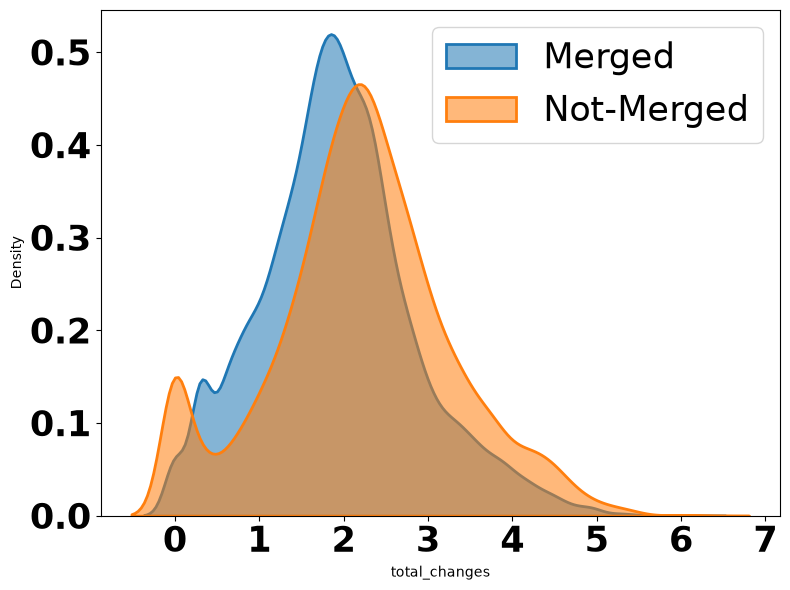

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Avoid zero values for log scale
merged_vals = merged["total_changes"].replace(0, 1)
not_vals = not_merged["total_changes"].replace(0, 1)

plt.figure(figsize=(8, 6))

# Plot KDEs
sns.kdeplot(
    np.log10(merged_vals),
    label="Merged",
    fill=True,
    alpha=0.55,
    linewidth=2
)
sns.kdeplot(
    np.log10(not_vals),
    label="Not-Merged",
    fill=True,
    alpha=0.55,
    linewidth=2
)

# --- Styling ---
# plt.xlabel("log10(Total Lines Changed)", fontsize=16, fontweight="bold")
# plt.ylabel("Density", fontsize=16, fontweight="bold")
# plt.title("Distribution of Lines Changed (log scale)", fontsize=18, fontweight="bold")

plt.xticks(fontsize=25, fontweight="bold")
plt.yticks(fontsize=25, fontweight="bold")

plt.legend(fontsize=25, title_fontsize=14)

plt.tight_layout()
plt.savefig("total_changes.png", dpi=300, bbox_inches="tight")
plt.show()


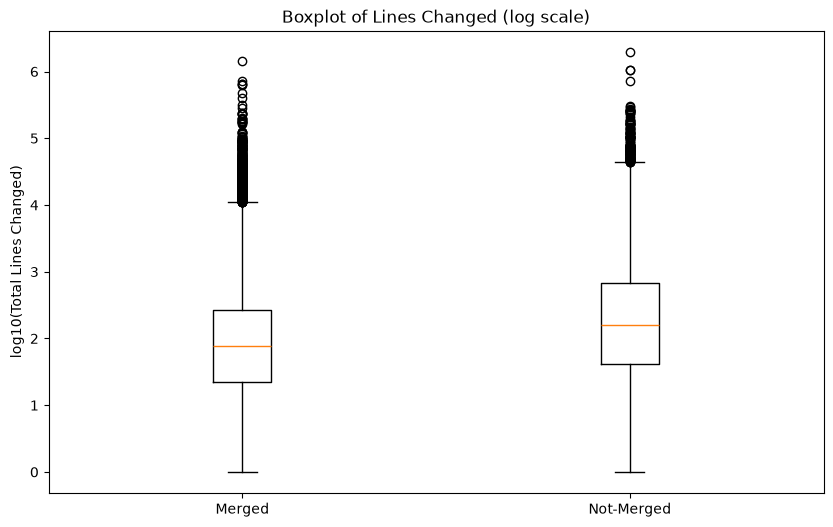

In [14]:
plt.figure(figsize=(10, 6))

plt.boxplot(
    [np.log10(merged_vals), np.log10(not_vals)],
    tick_labels=["Merged", "Not-Merged"],
    showfliers=True
)

plt.ylabel("log10(Total Lines Changed)")
plt.title("Boxplot of Lines Changed (log scale)")
plt.show()


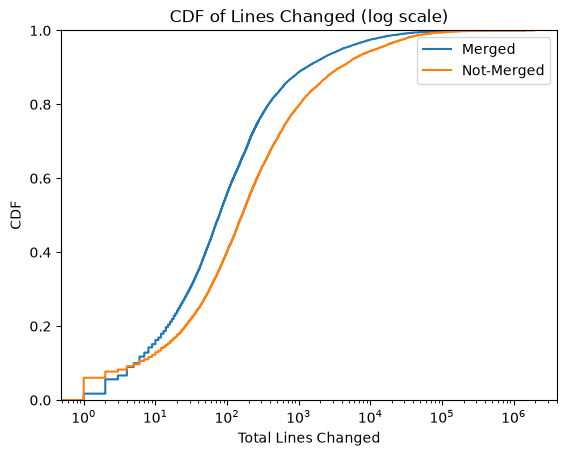

In [15]:
sns.ecdfplot(merged_vals, label="Merged")
sns.ecdfplot(not_vals, label="Not-Merged")
plt.xscale("log")
plt.xlabel("Total Lines Changed")
plt.ylabel("CDF")
plt.title("CDF of Lines Changed (log scale)")
plt.legend()
plt.show()


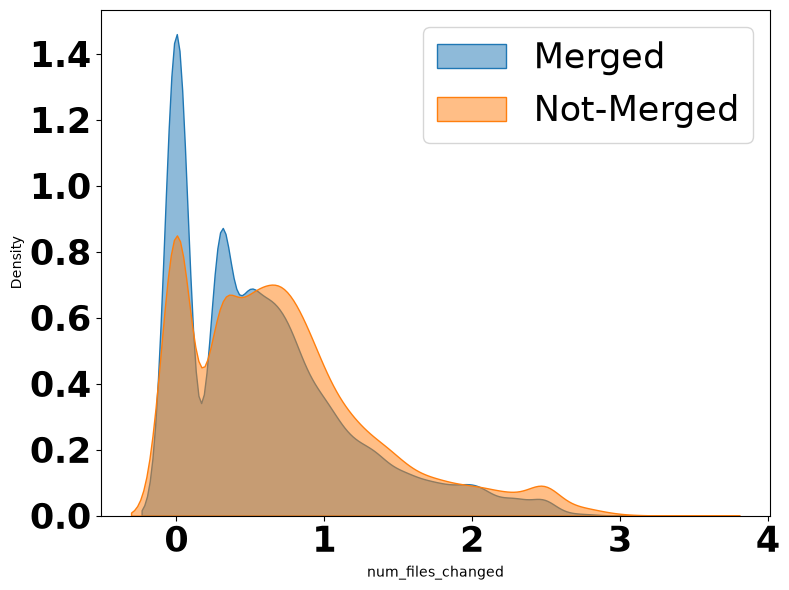

In [16]:
# Avoid zero values for log scale
merged_vals = merged["num_files_changed"].replace(0, 1)
not_vals = not_merged["num_files_changed"].replace(0, 1)

plt.figure(figsize=(8, 6))
sns.kdeplot(np.log10(merged_vals), label="Merged", fill=True, alpha=0.5)
sns.kdeplot(np.log10(not_vals), label="Not-Merged", fill=True, alpha=0.5)

# plt.xlabel("log10(Total Files Changed)", fontsize=16, fontweight="bold")
# plt.ylabel("Density", fontsize=16, fontweight="bold")
# plt.title("Distribution of Files Changed (log scale): Merged vs Not-Merged Agentic PRs",
#           fontsize=18, fontweight="bold")

plt.xticks(fontsize=25, fontweight="bold")
plt.yticks(fontsize=25, fontweight="bold")
plt.legend(fontsize=25, title_fontsize=14)

plt.tight_layout()
plt.savefig("num_files_changed.png", dpi=300, bbox_inches="tight")
plt.show()

In [17]:
import pandas as pd
from pathlib import Path
from IPython.display import display

from pathlib import Path

pull_request_path = None
for root in [Path("/kaggle/input"), Path(".")]:
    if root.exists():
        matches = list(root.rglob("pull_request.parquet"))
        if matches:
            pull_request_path = matches[0]
            break

if pull_request_path is None:
    raise FileNotFoundError(
        "pull_request.parquet not found under /kaggle/input. "
        "Attach it as a Kaggle Input dataset first."
    )

pull_requests = pd.read_parquet(pull_request_path)

review_comments_path = None
for root in [Path("/kaggle/input"), Path(".")]:
    if root.exists():
        matches = list(root.rglob("pr_review_comments_v2.parquet"))
        if matches:
            review_comments_path = matches[0]
            break

if review_comments_path is None:
    raise FileNotFoundError(
        "pr_review_comments_v2.parquet not found under /kaggle/input. "
        "Attach it as a Kaggle Input dataset first."
    )

print(f"Loading pr_review_comments_v2 from: {review_comments_path}")
pr_review_comments = pd.read_parquet(review_comments_path)

pr_review_comments["repo_url_extracted"] = pr_review_comments["pull_request_url"].str.extract(
    r"(https://api\.github\.com/repos/[^/]+/[^/]+)"
)
pr_review_comments["pr_number"] = pr_review_comments["pull_request_url"].str.extract(
    r"/pulls/(\d+)"
).astype(float)

pull_requests["repo_url_extracted"] = pull_requests["repo_url"]
pull_requests["pr_number"] = pull_requests["number"].astype(float)
pull_requests["agent"] = pull_requests["agent"].astype(str).str.lower()
pull_requests["merge_status"] = pull_requests["merged_at"].notna().map({True: "Merged", False: "Not-Merged"})

reviewed_prs = pull_requests.merge(
    pr_review_comments[["repo_url_extracted", "pr_number"]],
    on=["repo_url_extracted", "pr_number"],
    how="inner"
).drop_duplicates(subset="id")

print(f"Total review PR's {len(reviewed_prs):,}")

review_counts = pr_review_comments.groupby(
    ["repo_url_extracted", "pr_number"]
).size().reset_index(name="num_review_comments")

combined = reviewed_prs.merge(
    review_counts,
    on=["repo_url_extracted", "pr_number"],
    how="left"
)
combined["num_review_comments"] = combined["num_review_comments"].fillna(0)

combined = combined.merge(pr_stats, left_on="id", right_on="pr_id", how="left")
combined = combined.merge(pr_stats, left_on="id", right_on="pr_id", how="left")

metrics = (
    combined.groupby(["agent", "merge_status"])
    .agg(
        total_review_comments=("num_review_comments", "sum"),
        avg_review_comments=("num_review_comments", "mean"),
        total_reviewed_prs=("id", "count")
    )
    .reset_index()
    .round(2)
)

merged_table = metrics[metrics["merge_status"] == "Merged"].drop(columns="merge_status")
not_merged_table = metrics[metrics["merge_status"] == "Not-Merged"].drop(columns="merge_status")

merged_overall = merged_table.drop(columns=["agent"]).mean(numeric_only=True).to_frame().T
merged_overall["total_review_comments"] = merged_table["total_review_comments"].sum()
merged_overall["total_reviewed_prs"] = merged_table["total_reviewed_prs"].sum()
merged_overall.insert(0, "agent", "Overall")
merged_table = pd.concat([merged_table, merged_overall], ignore_index=True)

not_merged_overall = not_merged_table.drop(columns=["agent"]).mean(numeric_only=True).to_frame().T
not_merged_overall["total_review_comments"] = not_merged_table["total_review_comments"].sum()
not_merged_overall["total_reviewed_prs"] = not_merged_table["total_reviewed_prs"].sum()
not_merged_overall.insert(0, "agent", "Overall")
not_merged_table = pd.concat([not_merged_table, not_merged_overall], ignore_index=True)

def display_table(df, title):
    df_disp = df.rename(columns={
        "agent": "AI Agent",
        "total_review_comments": "Total #Review Comments",
        "avg_review_comments": "Average #Review Comments",
        "total_reviewed_prs": "Total Reviewed PRs"
    })
    print(f"\n{title}:")
    display(df_disp.style.format({
        "Average #Review Comments": "{:.2f}",
    }).hide(axis="index"))

display_table(merged_table, "Merged (Reviewed) PRs Summary per Agent")
display_table(not_merged_table, "Not-Merged (Reviewed) PRs Summary per Agent")

Loading pr_review_comments_v2 from: pr_review_comments_v2.parquet
Total review PR's 4,451

Merged (Reviewed) PRs Summary per Agent:


AI Agent,Total #Review Comments,Average #Review Comments,Total Reviewed PRs
claude_code,797,9.72,82
copilot,9589,9.43,1017
cursor,955,4.13,231
devin,3108,3.97,782
openai_codex,2840,3.52,806
Overall,17289,6.15,2918



Not-Merged (Reviewed) PRs Summary per Agent:


AI Agent,Total #Review Comments,Average #Review Comments,Total Reviewed PRs
claude_code,394,8.95,44
copilot,5647,8.53,662
cursor,501,4.25,118
devin,1880,4.85,388
openai_codex,1068,3.33,321
Overall,9490,5.98,1533


In [18]:
pull_requests["repo_url_extracted"] = pull_requests["repo_url"]
pull_requests["pr_number"] = pull_requests["number"].astype(float)

pull_requests = pull_requests.merge(
    review_counts,
    on=["repo_url_extracted", "pr_number"],
    how="left"
)
pull_requests["num_review_comments"] = pull_requests["num_review_comments"].fillna(0).astype(int)

pull_requests


,id,number,title,body,agent,user_id,user,state,created_at,closed_at,merged_at,repo_id,repo_url,html_url,repo_url_extracted,pr_number,merge_status,num_review_comments
0,3264933329,2911,Fix: Wait for all partitions in load_collectio...,## Summary\n\nFixes an issue where `load_colle...,claude_code,108661493,weiliu1031,closed,2025-07-26T02:59:01Z,2025-07-29T07:01:20Z,NaN,191751505,https://api.github.com/repos/milvus-io/pymilvus,https://github.com/milvus-io/pymilvus/pull/2911,https://api.github.com/repos/milvus-io/pymilvus,2911.0,Not-Merged,0
1,3265118634,2,ファイルパス参照を相対パスに統一し、doc/からdocs/に統一,## 背景\n\n現在、本プロジェクトにおいて以下のパス構成の不整合が生じています：\n\n...,claude_code,61827001,cm-kojimat,closed,2025-07-26T04:56:55Z,2025-07-26T22:12:24Z,2025-07-26T22:12:24Z,1025472321,https://api.github.com/repos/classmethod/tsumiki,https://github.com/classmethod/tsumiki/pull/2,https://api.github.com/repos/classmethod/tsumiki,2.0,Merged,0
2,3265640341,30,Add build staleness detection for debug CLI,## Summary\r\n\r\n Implements comprehensive b...,claude_code,7475,MSch,closed,2025-07-26T13:31:19Z,2025-07-26T13:37:22Z,2025-07-26T13:37:22Z,988488798,https://api.github.com/repos/steipete/Peekaboo,https://github.com/steipete/Peekaboo/pull/30,https://api.github.com/repos/steipete/Peekaboo,30.0,Merged,2
3,3265709660,205,feat: add comprehensive README screenshots wit...,## Type of Change\n\n- [ ] 🐛 `bug` - Bug fix (...,claude_code,80381,sugyan,closed,2025-07-26T14:07:22Z,2025-07-26T14:45:30Z,2025-07-26T14:45:30Z,999285986,https://api.github.com/repos/sugyan/claude-cod...,https://github.com/sugyan/claude-code-webui/pu...,https://api.github.com/repos/sugyan/claude-cod...,205.0,Merged,2
4,3265782173,17625,chore: remove HashedPostStateProvider trait,## Summary\r\n\r\n#17545 \r\n\r\nRemove the un...,claude_code,47593288,adust09,open,2025-07-26T15:02:48Z,NaN,NaN,537233603,https://api.github.com/repos/paradigmxyz/reth,https://github.com/paradigmxyz/reth/pull/17625,https://api.github.com/repos/paradigmxyz/reth,17625.0,Not-Merged,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33591,2857942945,2,fix: improve dark mode input focus and toggle ...,# UI Improvements: Dark Mode Input Focus and T...,devin,158243242,devin-ai-integration[bot],closed,2025-02-17T13:57:22Z,2025-02-17T14:40:12Z,2025-02-17T14:40:12Z,934090141,https://api.github.com/repos/jina-ai/deepsearc...,https://github.com/jina-ai/deepsearch-ui/pull/2,https://api.github.com/repos/jina-ai/deepsearc...,2.0,Merged,0
33592,2857959763,2154,docs: add required packages to SeleniumScrapin...,Fixes #2153\n\nThe SeleniumScrapingTool docume...,devin,158243242,devin-ai-integration[bot],closed,2025-02-17T14:04:15Z,2025-02-25T16:39:21Z,NaN,710601088,https://api.github.com/repos/crewAIInc/crewAI,https://github.com/crewAIInc/crewAI/pull/2154,https://api.github.com/repos/crewAIInc/crewAI,2154.0,Not-Merged,0
33593,2858280902,775,Fix heap buffer overflow in BundlePacket,This PR fixes a heap buffer overflow in Bundle...,devin,158243242,devin-ai-integration[bot],closed,2025-02-17T16:15:35Z,2025-02-17T16:23:53Z,NaN,21134745,https://api.github.com/repos/wolfSSL/wolfssh,https://github.com/wolfSSL/wolfssh/pull/775,https://api.github.com/repos/wolfSSL/wolfssh,775.0,Not-Merged,0
33594,2858429985,346,Improve environment variable documentation,# Environment Variable Documentation Improveme...,devin,158243242,devin-ai-integration[bot],closed,2025-02-17T17:19:32Z,2025-02-18T08:32:15Z,2025-02-18T08:32:15Z,894659403,https://api.github.com/repos/goat-sdk/goat,https://github.com/goat-sdk/goat/pull/346,https://api.github.com/repos/goat-sdk/goat,346.0,Merged,0


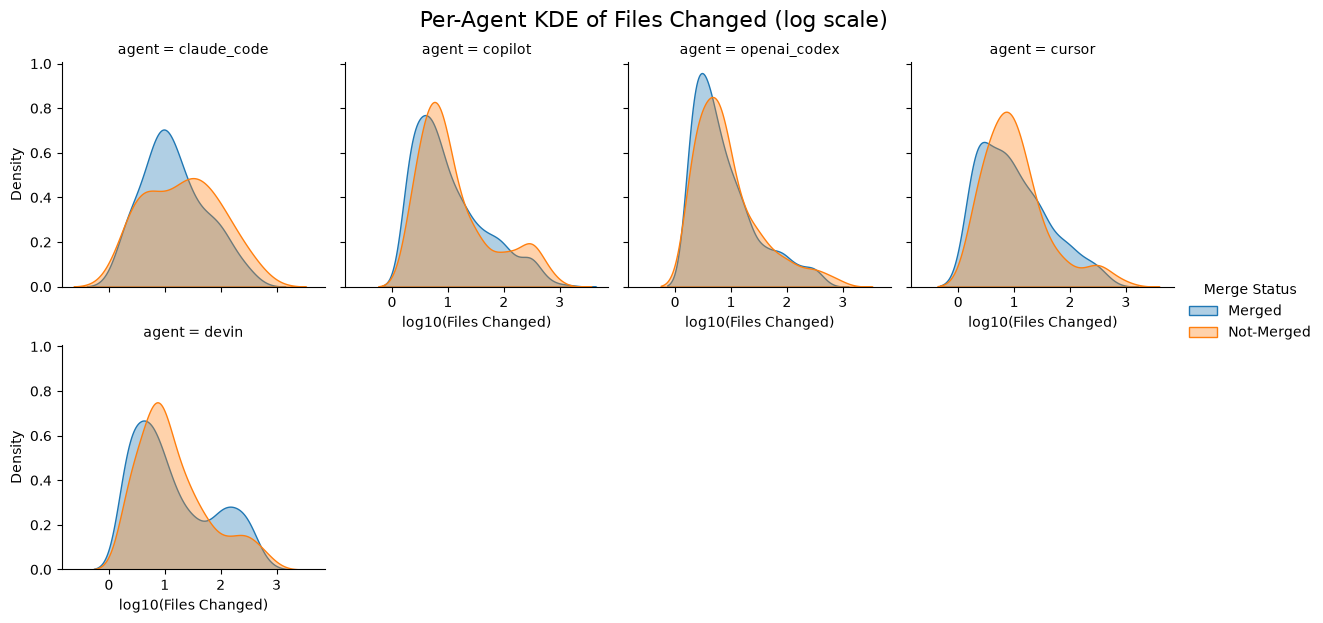

In [19]:
# Ensure combined has the size columns merged in (safe to re-run even if already merged)
if "num_files_changed" not in combined.columns:
    combined = combined.merge(pr_stats, left_on="id", right_on="pr_id", how="left")

# Filter to agentic PRs
ai_data = combined[combined["agent"].isin(ai_agents)].copy()

# Add log10 transform (avoid log(0))
ai_data["log_files_changed"] = np.log10(ai_data["num_files_changed"] + 1)

# Create FacetGrid: one panel per agent
g = sns.FacetGrid(
    ai_data,
    col="agent",
    hue="merge_status",
    col_wrap=4,
    height=3,
    sharex=True,
    sharey=True
)

# Map KDE plot
g.map(sns.kdeplot, "log_files_changed", fill=True, alpha=0.35)
g.add_legend(title="Merge Status")
g.set_axis_labels("log10(Files Changed)", "Density")
g.fig.suptitle("Per-Agent KDE of Files Changed (log scale)", y=1.03, fontsize=16)
plt.show()

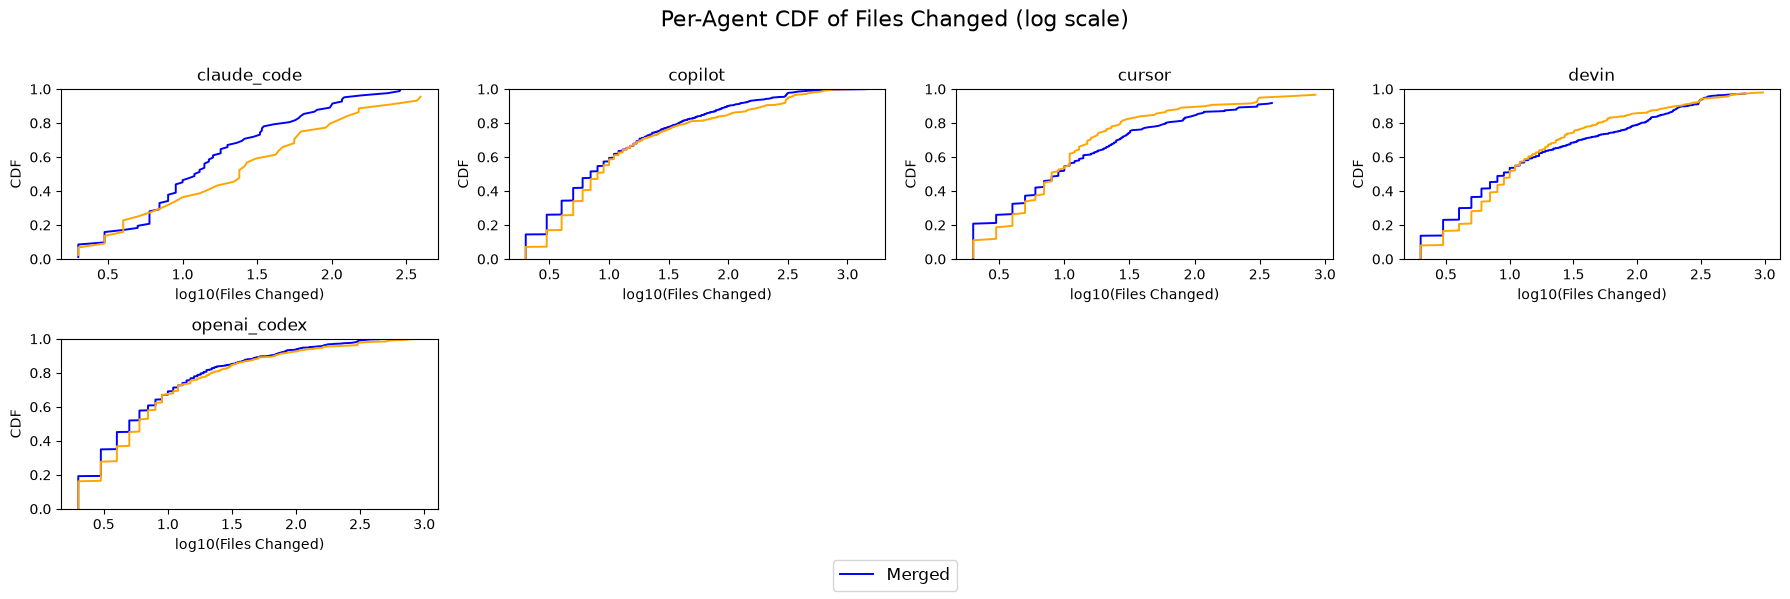

In [20]:
ai_data = combined[combined["agent"].isin(ai_agents)].copy()
ai_data["log_files_changed"] = np.log10(ai_data["num_files_changed"] + 1)

agents_sorted = sorted(ai_agents)

num_agents = len(agents_sorted)
cols = 4
rows = int(np.ceil(num_agents / cols))

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 3))
axes = axes.flatten()

# To store handles and labels for legend
handles = None
labels = None

for ax, agent in zip(axes, agents_sorted):
    df = ai_data[ai_data["agent"] == agent]

    for status, color in [("Merged", "blue"), ("Not-Merged", "orange")]:
        group = df[df["merge_status"] == status]["log_files_changed"].values
        group = np.sort(group)

        if len(group) > 0:
            cdf = np.arange(1, len(group) + 1) / len(group)
            line, = ax.plot(group, cdf, label=status, linewidth=1.4, color=color)

            # Collect legend handles from first subplot with valid data
            if handles is None:
                handles, labels = ax.get_legend_handles_labels()

    ax.set_title(agent)
    ax.set_xlabel("log10(Files Changed)")
    ax.set_ylabel("CDF")
    ax.set_ylim(0, 1)

# Turn off empty axes
for ax in axes[len(agents_sorted):]:
    ax.axis("off")

fig.suptitle("Per-Agent CDF of Files Changed (log scale)", fontsize=16)

# Add global legend using stored handles/labels
fig.legend(handles, labels, loc="lower center", ncol=2, fontsize=12)

fig.tight_layout(rect=[0, 0.05, 1, 0.97])
plt.show()

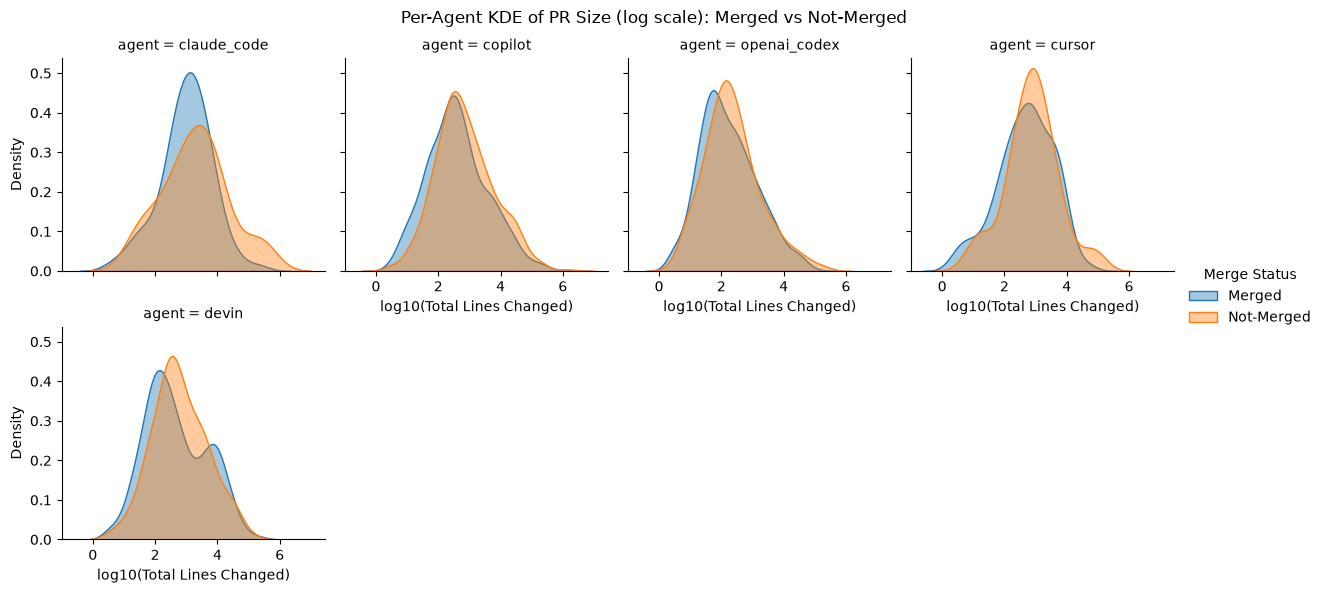

In [21]:
ai_data = combined[combined["agent"].isin(ai_agents)].copy()
ai_data["log_total_changes"] = np.log10(ai_data["total_changes"] + 1)

g = sns.FacetGrid(
    ai_data,
    col="agent",
    hue="merge_status",
    col_wrap=4,
    sharex=True,
    sharey=True,
    height=3
)

g.map(sns.kdeplot, "log_total_changes", fill=True, alpha=0.4)

g.add_legend(title="Merge Status")
g.set_axis_labels("log10(Total Lines Changed)", "Density")
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Per-Agent KDE of PR Size (log scale): Merged vs Not-Merged")

plt.show()

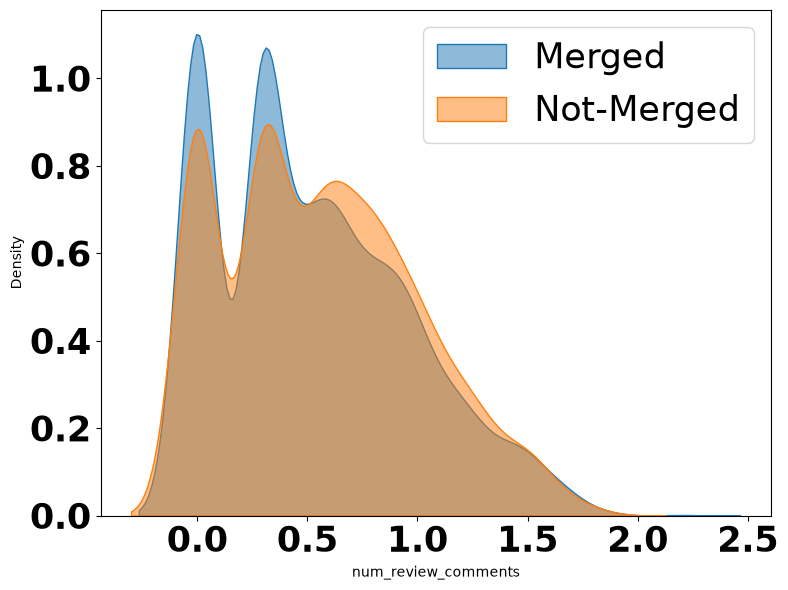

In [22]:
# Split into merged / not merged just like your other KDEs
merged_vals = combined.loc[combined["merge_status"] == "Merged", "num_review_comments"]
not_vals = combined.loc[combined["merge_status"] == "Not-Merged", "num_review_comments"]

# Avoid zeros for log scale (if needed)
merged_vals = merged_vals.replace(0, 1)
not_vals = not_vals.replace(0, 1)

plt.figure(figsize=(8, 6))

sns.kdeplot(np.log10(merged_vals),
            label="Merged",
            fill=True,
            alpha=0.5)

sns.kdeplot(np.log10(not_vals),
            label="Not-Merged",
            fill=True,
            alpha=0.5)

# plt.xlabel("log10(# Review Comments)", fontsize=20, fontweight="bold")
# plt.ylabel("Density", fontsize=20, fontweight="bold")
# plt.title("Distribution of Review Comments (log scale): Merged vs Not-Merged",
#           fontsize=22, fontweight="bold")

plt.xticks(fontsize=25, fontweight="bold")
plt.yticks(fontsize=25, fontweight="bold")

plt.legend(fontsize=25, title_fontsize=18)

plt.tight_layout()
plt.savefig("num_review_comments_kde.png", dpi=300, bbox_inches="tight")
plt.show()

In [23]:
def cliffs_delta(x, y):
    nx, ny = len(x), len(y)
    more = sum(i > j for i in x for j in y)
    less = sum(i < j for i in x for j in y)
    return (more - less) / (nx * ny)

merged = combined[combined["merge_status"] == "Merged"]
not_merged = combined[combined["merge_status"] == "Not-Merged"]

delta_num_review_comments = cliffs_delta(merged["num_review_comments"], not_merged["num_review_comments"])
# delta_files = cliffs_delta(merged_table["num_files_changed"], not_merged["num_files_changed"])

print("Cliff's delta (num_review_comments):", round(delta_num_review_comments, 3))
# print("Cliff's delta (files changed):", round(delta_files, 3))


Cliff's delta (num_review_comments): -0.052


In [24]:
def cliffs_delta(x, y):
    nx, ny = len(x), len(y)
    more = sum(i > j for i in x for j in y)
    less = sum(i < j for i in x for j in y)
    return (more - less) / (nx * ny)

merged = combined[combined["merge_status"] == "Merged"]
not_merged = combined[combined["merge_status"] == "Not-Merged"]

delta_reviews = cliffs_delta(merged["num_review_comments"], not_merged["num_review_comments"])

print("Cliff's delta (number of reviews):", round(delta_reviews, 3))


Cliff's delta (number of reviews): -0.052


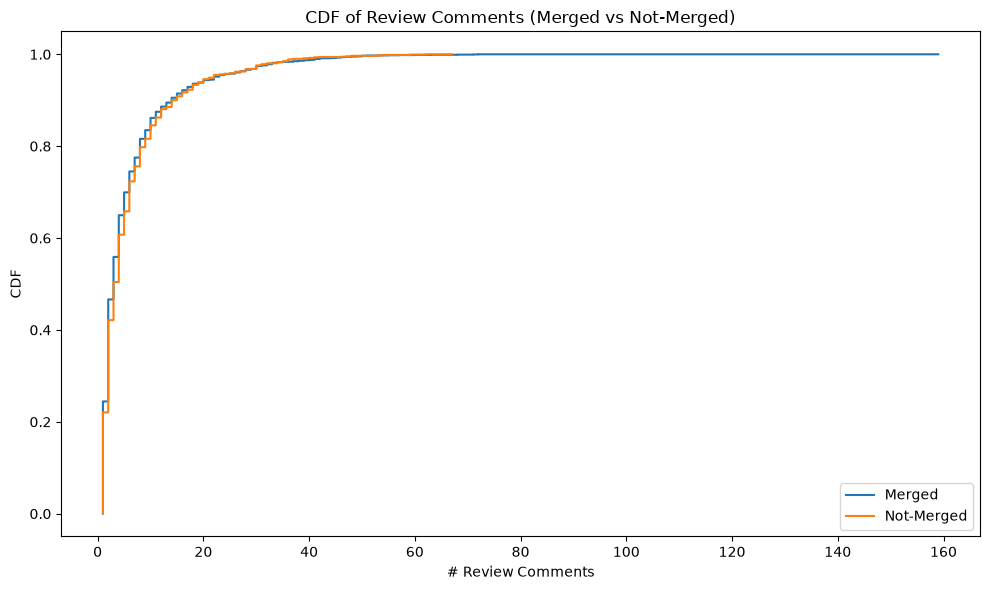

In [25]:
merged = np.sort(combined[combined["merge_status"]=="Merged"]["num_review_comments"])
not_merged = np.sort(combined[combined["merge_status"]=="Not-Merged"]["num_review_comments"])

cdf_m = np.arange(1, len(merged)+1) / len(merged)
cdf_nm = np.arange(1, len(not_merged)+1) / len(not_merged)

plt.figure(figsize=(10,6))
plt.step(merged, cdf_m, label="Merged")
plt.step(not_merged, cdf_nm, label="Not-Merged")

plt.xlabel("# Review Comments")
plt.ylabel("CDF")
plt.title("CDF of Review Comments (Merged vs Not-Merged)")
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
import pandas as pd
from pathlib import Path
# from tabulate import tabulate

from pathlib import Path

pull_request_path = None
for root in [Path("/kaggle/input"), Path(".")]:
    if root.exists():
        matches = list(root.rglob("pull_request.parquet"))
        if matches:
            pull_request_path = matches[0]
            break

if pull_request_path is None:
    raise FileNotFoundError(
        "pull_request.parquet not found under /kaggle/input. "
        "Attach it as a Kaggle Input dataset first."
    )

pull_requests = pd.read_parquet(pull_request_path)

task_type_path = None
for root in [Path("/kaggle/input"), Path(".")]:
    if root.exists():
        matches = list(root.rglob("pr_task_type.parquet"))
        if matches:
            task_type_path = matches[0]
            break

if task_type_path is None:
    raise FileNotFoundError(
        "pr_task_type.parquet not found under /kaggle/input. "
        "Attach it as a Kaggle Input dataset first."
    )

print(f"Loading pr_task_type from: {task_type_path}")
pr_task_type = pd.read_parquet(task_type_path)

pull_requests["merge_status"] = pull_requests["merged_at"].notna().map({True: "Merged", False: "Not-Merged"})
pr_task_type["type"] = pr_task_type["type"].astype(str).str.strip().str.title()
pr_task_type = pr_task_type[pr_task_type["type"].notna() & (pr_task_type["type"] != "Nan")]

merged_df = pr_task_type.merge(pull_requests[["id", "merge_status"]], on="id", how="left")

task_summary = (
    merged_df.groupby(["type", "merge_status"])
    .size()
    .reset_index(name="count")
    .pivot(index="type", columns="merge_status", values="count")
    .fillna(0)
    .astype(int)
    .reset_index()
)

if "Merged" not in task_summary.columns:
    task_summary["Merged"] = 0
if "Not-Merged" not in task_summary.columns:
    task_summary["Not-Merged"] = 0

task_summary = task_summary[["type", "Merged", "Not-Merged"]]
task_summary["Total PRs"] = task_summary["Merged"] + task_summary["Not-Merged"]
task_summary["% Merged"] = (task_summary["Merged"] / task_summary["Total PRs"] * 100).round(2)
task_summary["% Not-Merged"] = (task_summary["Not-Merged"] / task_summary["Total PRs"] * 100).round(2)

unique_types = sorted(task_summary["type"].unique().tolist())
print(f"Total unique task types: {len(unique_types)}")
print(f"Task types: {unique_types}\n")

print("Pull Request Task-Type Summary:")
task_summary = task_summary.rename(columns={
    "type": "Task Type",
    "Merged": "# Merged PRs",
    "Not-Merged": "# Not-Merged PRs",
    "% Merged": "% Merged",
    "% Not-Merged": "% Not-Merged"
})
task_summary = task_summary.reset_index(drop=True)

display(task_summary.style.format({
    "% Merged": "{:.2f}",
    "% Not-Merged": "{:.2f}"
}).hide(axis="index"))

Loading pr_task_type from: pr_task_type.parquet
Total unique task types: 12
Task types: ['Build', 'Chore', 'Ci', 'Docs', 'Feat', 'Fix', 'Other', 'Perf', 'Refactor', 'Revert', 'Style', 'Test']

Pull Request Task-Type Summary:


Task Type,# Merged PRs,# Not-Merged PRs,Total PRs,% Merged,% Not-Merged
Build,469,158,627,74.80,25.20
Chore,616,280,896,68.75,31.25
Ci,325,86,411,79.08,20.92
Docs,3267,620,3887,84.05,15.95
Feat,10270,4180,14450,71.07,28.93
Fix,5267,2839,8106,64.98,35.02
Other,3,28,31,9.68,90.32
Perf,188,152,340,55.29,44.71
Refactor,1604,684,2288,70.10,29.90
Revert,12,4,16,75.00,25.00


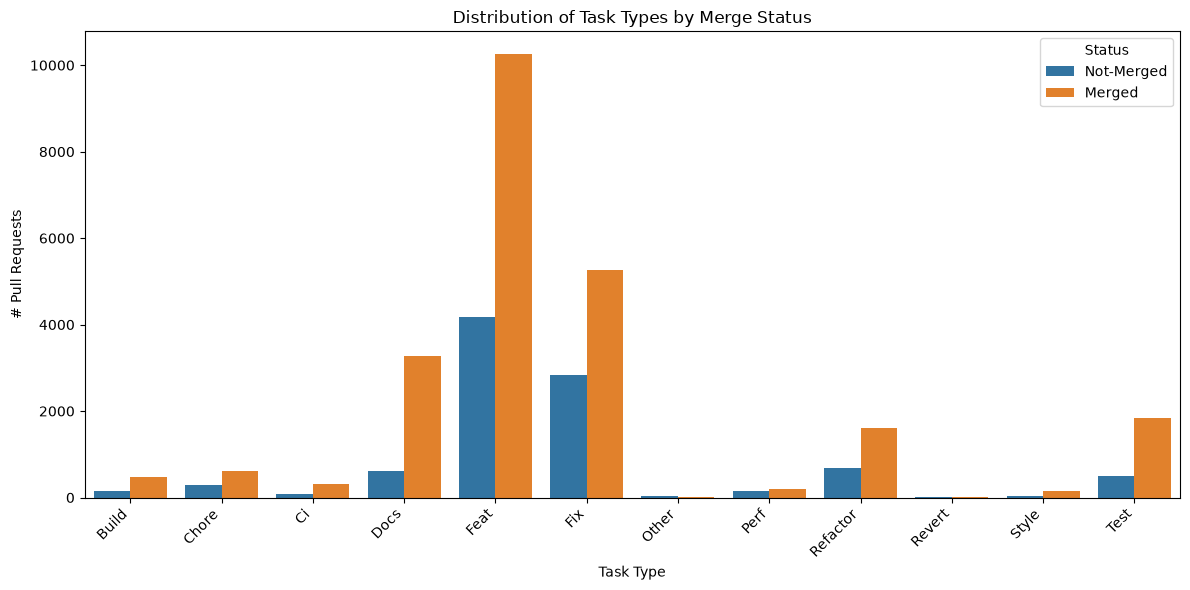

In [27]:
plt.figure(figsize=(12,6))
sns.countplot(
    data=merged_df, 
    x="type", 
    hue="merge_status",
    order=task_summary["Task Type"]
)

plt.xticks(rotation=45, ha='right')
plt.xlabel("Task Type")
plt.ylabel("# Pull Requests")
plt.title("Distribution of Task Types by Merge Status")
plt.legend(title="Status")
plt.tight_layout()
plt.show()

In [28]:
import pandas as pd
from tabulate import tabulate

from pathlib import Path

pull_request_path = None
for root in [Path("/kaggle/input"), Path(".")]:
    if root.exists():
        matches = list(root.rglob("pull_request.parquet"))
        if matches:
            pull_request_path = matches[0]
            break

if pull_request_path is None:
    raise FileNotFoundError(
        "pull_request.parquet not found under /kaggle/input. "
        "Attach it as a Kaggle Input dataset first."
    )

pull_requests = pd.read_parquet(pull_request_path)

pull_requests["agent"] = pull_requests["agent"].astype(str).str.lower()
ai_agents = sorted(pull_requests["agent"].dropna().unique().tolist())

pull_requests["is_merged"] = pull_requests["merged_at"].notna().astype(int)

summary = (
    pull_requests[pull_requests["agent"].isin(ai_agents)]
    .groupby("agent")
    .agg(
        total_prs=("id", "count"),
        merged_prs=("is_merged", "sum")
    )
    .reset_index()
)

summary["percentage_merged"] = (summary["merged_prs"] / summary["total_prs"] * 100).round(2)

overall = pd.DataFrame({
    "agent": ["Overall"],
    "total_prs": [summary["total_prs"].sum()],
    "merged_prs": [summary["merged_prs"].sum()],
    "percentage_merged": [(summary["merged_prs"].sum() / summary["total_prs"].sum() * 100).round(2)]
})

summary = pd.concat([summary, overall], ignore_index=True)

print("Pull Request Merge Success Rate per Agent:")
summary_disp = summary.rename(columns={
    "agent": "Agents",
    "total_prs": "Total PRs",
    "percentage_merged": "Percentage Merged"
})[["Agents", "Total PRs", "Percentage Merged"]]

display(summary_disp.style.format({
    "Percentage Merged": "{:.2f}"
}).hide(axis="index"))

Pull Request Merge Success Rate per Agent:


Agents,Total PRs,Percentage Merged
claude_code,459,59.04
copilot,4970,43.04
cursor,1541,65.22
devin,4827,53.76
openai_codex,21799,82.59
Overall,33596,71.48


In [29]:
import pandas as pd
from pathlib import Path
from IPython.display import display

from pathlib import Path

pull_request_path = None
for root in [Path("/kaggle/input"), Path(".")]:
    if root.exists():
        matches = list(root.rglob("pull_request.parquet"))
        if matches:
            pull_request_path = matches[0]
            break

if pull_request_path is None:
    raise FileNotFoundError(
        "pull_request.parquet not found under /kaggle/input. "
        "Attach it as a Kaggle Input dataset first."
    )

pull_requests = pd.read_parquet(pull_request_path)

task_type_path = None
for root in [Path("/kaggle/input"), Path(".")]:
    if root.exists():
        matches = list(root.rglob("pr_task_type.parquet"))
        if matches:
            task_type_path = matches[0]
            break

if task_type_path is None:
    raise FileNotFoundError(
        "pr_task_type.parquet not found under /kaggle/input. "
        "Attach it as a Kaggle Input dataset first."
    )

print(f"Loading pr_task_type from: {task_type_path}")
pr_task_type = pd.read_parquet(task_type_path)

pull_requests["agent"] = pull_requests["agent"].astype(str).str.lower()
ai_agents = sorted(pull_requests["agent"].dropna().unique().tolist())

pr_task_type["type"] = pr_task_type["type"].astype(str).str.strip().str.title()
pr_task_type = pr_task_type[pr_task_type["type"].notna() & (pr_task_type["type"] != "Nan")]

merged_df = pr_task_type.merge(
    pull_requests[["id", "agent"]],
    on="id",
    how="left",
    suffixes=("_task", "_pr")
)

if "agent_pr" in merged_df.columns:
    merged_df["agent"] = merged_df["agent_pr"].fillna(merged_df.get("agent_task"))
elif "agent" not in merged_df.columns and "agent_task" in merged_df.columns:
    merged_df["agent"] = merged_df["agent_task"]

task_summary = (
    merged_df[merged_df["agent"].isin(ai_agents)]
    .groupby(["agent", "type"])
    .size()
    .reset_index(name="count")
)

pivot_summary = (
    task_summary
    .pivot(index="agent", columns="type", values="count")
    .fillna(0)
    .astype(int)
    .reset_index()
)

pivot_summary["Total PRs"] = pivot_summary.drop(columns=["agent"]).sum(axis=1)
overall = pivot_summary.drop(columns=["agent"]).sum(numeric_only=True).to_frame().T
overall.insert(0, "agent", "Overall")
pivot_summary = pd.concat([pivot_summary, overall], ignore_index=True)

print("Pull Request Task-Type Distribution per Agent:")
display(pivot_summary.style.hide(axis="index"))

Loading pr_task_type from: pr_task_type.parquet
Pull Request Task-Type Distribution per Agent:


agent,Build,Chore,Ci,Docs,Feat,Fix,Other,Perf,Refactor,Revert,Style,Test,Total PRs
claude_code,8,14,5,32,250,115,0,3,26,0,0,6,459
copilot,121,126,67,458,1661,1993,12,44,301,5,15,167,4970
cursor,42,50,16,207,616,411,9,24,111,0,18,37,1541
devin,64,281,59,620,1904,1249,3,62,437,6,25,117,4827
openai_codex,392,425,264,2570,10019,4338,7,207,1413,5,130,2029,21799
Overall,627,896,411,3887,14450,8106,31,340,2288,16,188,2356,33596


In [30]:
import pandas as pd
from pathlib import Path
from IPython.display import display, HTML

from pathlib import Path

pull_request_path = None
for root in [Path("/kaggle/input"), Path(".")]:
    if root.exists():
        matches = list(root.rglob("pull_request.parquet"))
        if matches:
            pull_request_path = matches[0]
            break

if pull_request_path is None:
    raise FileNotFoundError(
        "pull_request.parquet not found under /kaggle/input. "
        "Attach it as a Kaggle Input dataset first."
    )

pull_requests = pd.read_parquet(pull_request_path)

task_type_path = None
for root in [Path("/kaggle/input"), Path(".")]:
    if root.exists():
        matches = list(root.rglob("pr_task_type.parquet"))
        if matches:
            task_type_path = matches[0]
            break

if task_type_path is None:
    raise FileNotFoundError(
        "pr_task_type.parquet not found under /kaggle/input. "
        "Attach it as a Kaggle Input dataset first."
    )

print(f"Loading pr_task_type from: {task_type_path}")
pr_task_type = pd.read_parquet(task_type_path)

pull_requests["agent"] = pull_requests["agent"].astype(str).str.lower()
ai_agents = sorted(pull_requests["agent"].dropna().unique().tolist())
pull_requests["merge_status"] = pull_requests["merged_at"].notna().map({True: "Merged", False: "Not-Merged"})

pr_task_type["type"] = pr_task_type["type"].astype(str).str.strip().str.title()
pr_task_type = pr_task_type[pr_task_type["type"].notna() & (pr_task_type["type"] != "Nan")]

merged_df = pr_task_type.merge(
    pull_requests[["id", "agent", "merge_status"]],
    on="id",
    how="left",
    suffixes=("_task", "_pr")
)

if "agent_pr" in merged_df.columns:
    merged_df["agent"] = merged_df["agent_pr"].fillna(merged_df.get("agent_task"))
elif "agent" not in merged_df.columns and "agent_task" in merged_df.columns:
    merged_df["agent"] = merged_df["agent_task"]

task_summary = (
    merged_df[merged_df["agent"].isin(ai_agents)]
    .groupby(["agent", "type", "merge_status"])
    .size()
    .reset_index(name="count")
)

pivot_summary = (
    task_summary
    .pivot(index=["agent", "type"], columns="merge_status", values="count")
    .fillna(0)
    .astype(int)
    .reset_index()
)

for col in ["Merged", "Not-Merged"]:
    if col not in pivot_summary.columns:
        pivot_summary[col] = 0

pivot_summary["Total PRs"] = pivot_summary["Merged"] + pivot_summary["Not-Merged"]
pivot_summary["% Merged"] = (pivot_summary["Merged"] / pivot_summary["Total PRs"] * 100).round(2)
pivot_summary["% Not-Merged"] = (pivot_summary["Not-Merged"] / pivot_summary["Total PRs"] * 100).round(2)

for agent in ai_agents:
    agent_df = pivot_summary[pivot_summary["agent"] == agent].copy()
    agent_df = agent_df.sort_values(by="Total PRs", ascending=False)
    cols = ["type", "Merged", "Not-Merged", "Total PRs", "% Merged", "% Not-Merged"]
    print(f"\nAgent: {agent}")
    display(
        agent_df[cols]
        .rename(columns={
            "type": "Task Type",
            "Merged": "# Merged PRs",
            "Not-Merged": "# Not-Merged PRs",
            "Total PRs": "Total PRs",
            "% Merged": "% Merged",
            "% Not-Merged": "% Not-Merged"
        })
        .style
        .hide(axis="index")
        .format({
            "% Merged": "{:.2f}",
            "% Not-Merged": "{:.2f}"
        })
    )

Loading pr_task_type from: pr_task_type.parquet

Agent: claude_code


Task Type,# Merged PRs,# Not-Merged PRs,Total PRs,% Merged,% Not-Merged
Feat,142,108,250,56.80,43.20
Fix,66,49,115,57.39,42.61
Docs,24,8,32,75.00,25.00
Refactor,13,13,26,50.00,50.00
Chore,10,4,14,71.43,28.57
Build,7,1,8,87.50,12.50
Test,3,3,6,50.00,50.00
Ci,4,1,5,80.00,20.00
Perf,2,1,3,66.67,33.33



Agent: copilot


Task Type,# Merged PRs,# Not-Merged PRs,Total PRs,% Merged,% Not-Merged
Fix,845,1148,1993,42.40,57.60
Feat,632,1029,1661,38.05,61.95
Docs,278,180,458,60.70,39.30
Refactor,144,157,301,47.84,52.16
Test,61,106,167,36.53,63.47
Chore,55,71,126,43.65,56.35
Build,60,61,121,49.59,50.41
Ci,42,25,67,62.69,37.31
Perf,12,32,44,27.27,72.73
Style,6,9,15,40.00,60.00



Agent: cursor


Task Type,# Merged PRs,# Not-Merged PRs,Total PRs,% Merged,% Not-Merged
Feat,372,244,616,60.39,39.61
Fix,281,130,411,68.37,31.63
Docs,154,53,207,74.40,25.60
Refactor,72,39,111,64.86,35.14
Chore,37,13,50,74.00,26.00
Build,24,18,42,57.14,42.86
Test,23,14,37,62.16,37.84
Perf,11,13,24,45.83,54.17
Style,13,5,18,72.22,27.78
Ci,15,1,16,93.75,6.25



Agent: devin


Task Type,# Merged PRs,# Not-Merged PRs,Total PRs,% Merged,% Not-Merged
Feat,1035,869,1904,54.36,45.64
Fix,536,713,1249,42.91,57.09
Docs,442,178,620,71.29,28.71
Refactor,248,189,437,56.75,43.25
Chore,159,122,281,56.58,43.42
Test,59,58,117,50.43,49.57
Build,37,27,64,57.81,42.19
Perf,22,40,62,35.48,64.52
Ci,36,23,59,61.02,38.98
Style,17,8,25,68.00,32.00



Agent: openai_codex


Task Type,# Merged PRs,# Not-Merged PRs,Total PRs,% Merged,% Not-Merged
Feat,8089,1930,10019,80.74,19.26
Fix,3539,799,4338,81.58,18.42
Docs,2369,201,2570,92.18,7.82
Test,1701,328,2029,83.83,16.17
Refactor,1127,286,1413,79.76,20.24
Chore,355,70,425,83.53,16.47
Build,341,51,392,86.99,13.01
Ci,228,36,264,86.36,13.64
Perf,141,66,207,68.12,31.88
Style,110,20,130,84.62,15.38


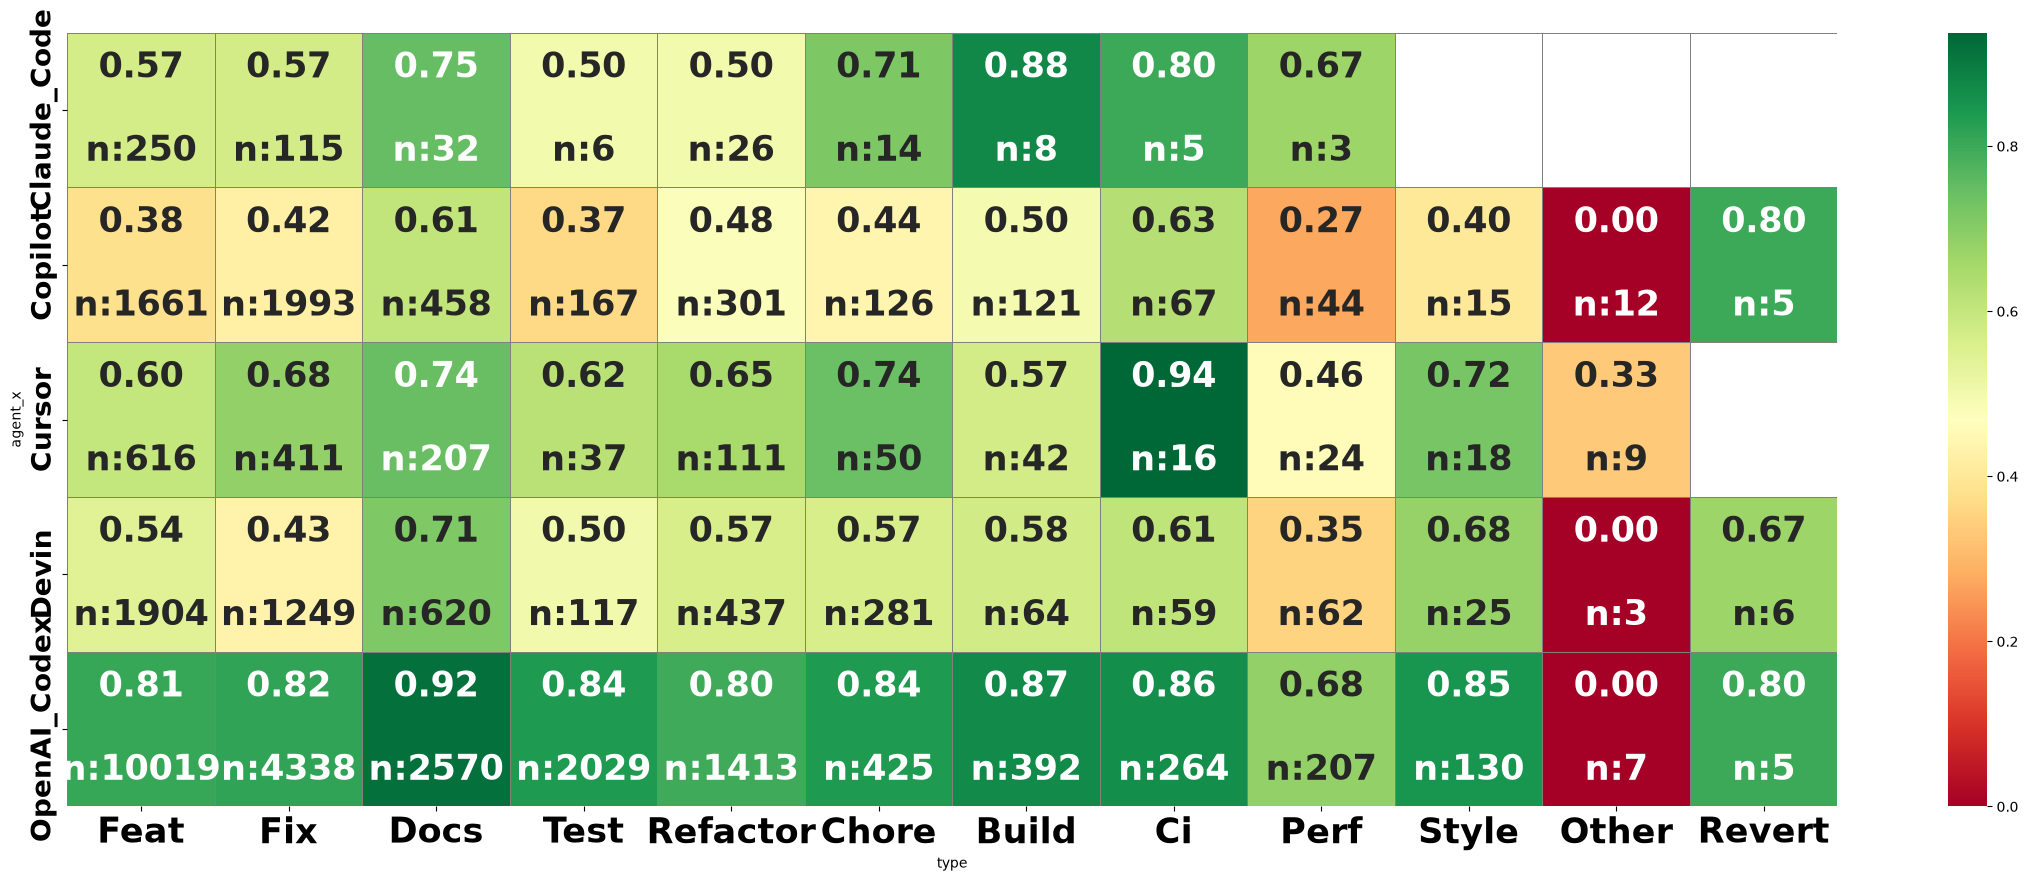

In [31]:
# --- Prepare Data ---
pull_requests["merge_status"] = pull_requests["merged_at"].notna()

merged_status_df = pr_task_type.merge(
    pull_requests[["id", "agent", "merge_status"]],
    on="id",
    how="left"
)

# Count how many PRs per (agent, task)
task_counts = (
    merged_status_df.groupby(["agent_x", "type"])
    .size()
    .unstack()
)

# Compute merge rate
merge_rates = (
    merged_status_df.groupby(["agent_x", "type"])["merge_status"]
    .mean()
    .unstack()
)

# -------- Sort task types by total frequency --------
task_order = task_counts.sum(axis=0).sort_values(ascending=False).index
if "other" in task_order:
    task_order = task_order.drop("other")

task_counts = task_counts[task_order]
merge_rates = merge_rates[task_order]
merge_rates = merge_rates.apply(pd.to_numeric, errors="coerce")  # fix: force numeric dtype for heatmap

# -------- Build annotation matrix --------
annot = merge_rates.copy().astype(object)
for agent in merge_rates.index:
    for task in merge_rates.columns:
        count = task_counts.loc[agent, task]
        if pd.isna(merge_rates.loc[agent, task]):  # no data
            annot.loc[agent, task] = f"0\n(n=0)"
        else:
            rate = merge_rates.loc[agent, task]
            annot.loc[agent, task] = f"{rate:.2f}\n\nn:{int(count)}"

# -------- Mask missing values so they are white --------
mask = merge_rates.isna()

# -------- Plot heatmap --------
plt.figure(figsize=(23, 9))

ax = sns.heatmap(
    merge_rates,
    annot=annot,
    fmt="",
    cmap="RdYlGn",
    mask=mask,
    cbar=True,
    linewidths=0.5,
    linecolor="gray",
    square=False,
)

# ----- STYLING -----
ax.set_xticklabels(ax.get_xticklabels(), fontsize=25, fontweight="bold")
ax.set_yticklabels(ax.get_yticklabels(), fontsize=20, fontweight="bold")

for text in ax.texts:
    text.set_fontsize(25)
    text.set_fontweight("bold")

# plt.title("Merge Rate per Task Type per Agent")
# plt.xlabel("Task Type")
# plt.ylabel("Agent")
plt.tight_layout()
plt.savefig("merge_rate_per_task_type_per_agent.png", dpi=300, bbox_inches="tight")
plt.show()

In [32]:
merged_status_df

,agent_x,id,title,reason,type,confidence,agent_y,merge_status
0,Claude_Code,3264933329,Fix: Wait for all partitions in load_collectio...,title provides conventional commit label,Fix,10,claude_code,False
1,Claude_Code,3265709660,feat: add comprehensive README screenshots wit...,title provides conventional commit label,Feat,10,claude_code,True
2,Claude_Code,3265782173,chore: remove HashedPostStateProvider trait,title provides conventional commit label,Chore,10,claude_code,False
3,Claude_Code,3231949586,feat(swagger): Add Swagger annotations to Batc...,title provides conventional commit label,Feat,10,claude_code,False
4,Claude_Code,3231950376,feat(swagger): Add Swagger annotations to Batc...,title provides conventional commit label,Feat,10,claude_code,False
...,...,...,...,...,...,...,...,...
33591,Devin,2857168507,Add close button to settings modal,The commit introduces a new feature by adding ...,Feat,9,devin,True
33592,Devin,2858527610,Add Doxygen Documentation for Public APIs,The changes involve adding comprehensive Doxyg...,Docs,10,devin,False
33593,Devin,2858429985,Improve environment variable documentation,The PR focuses on improving and adding documen...,Docs,10,devin,True
33594,Devin,3260345989,Match dividend check pattern to invoice requir...,The change updates the eligibility check logic...,Refactor,8,devin,True


## Size of Revisions for reviewed PRs

In [33]:
import pandas as pd
from pathlib import Path

from pathlib import Path

pull_request_path = None
for root in [Path("/kaggle/input"), Path(".")]:
    if root.exists():
        matches = list(root.rglob("pull_request.parquet"))
        if matches:
            pull_request_path = matches[0]
            break

if pull_request_path is None:
    raise FileNotFoundError(
        "pull_request.parquet not found under /kaggle/input. "
        "Attach it as a Kaggle Input dataset first."
    )

pull_requests = pd.read_parquet(pull_request_path)
pr_reviews = load_aidev_table("pr_reviews")

review_comments_path = None
for root in [Path("/kaggle/input"), Path(".")]:
    if root.exists():
        matches = list(root.rglob("pr_review_comments_v2.parquet"))
        if matches:
            review_comments_path = matches[0]
            break

if review_comments_path is None:
    raise FileNotFoundError(
        "pr_review_comments_v2.parquet not found under /kaggle/input. "
        "Attach it as a Kaggle Input dataset first."
    )

print(f"Loading pr_review_comments_v2 from: {review_comments_path}")
pr_review_comments = pd.read_parquet(review_comments_path)

Loading pr_review_comments_v2 from: pr_review_comments_v2.parquet


In [34]:
pr_review_comments["pr_number"] = (
    pr_review_comments["pull_request_url"]
    .str.rstrip("/")
    .str.split("/")
    .str[-1]
    .astype(int)
)
def count_add_del(hunk):
    if not isinstance(hunk, str):
        return 0, 0

    additions = 0
    deletions = 0
    
    for line in hunk.splitlines():
        # Skip diff headers
        if line.startswith("+++") or line.startswith("---") or line.startswith("@@"):
            continue
        if line.startswith("+"):
            additions += 1
        elif line.startswith("-"):
            deletions += 1
    return additions, deletions

# Apply to each row
parsed = pr_review_comments["diff_hunk"].apply(count_add_del)
pr_review_comments["additions"] = parsed.apply(lambda t: t[0])
pr_review_comments["deletions"] = parsed.apply(lambda t: t[1])
review_stats = (
    pr_review_comments
    .groupby("pull_request_url")
    .agg(
        review_additions=("additions", "sum"),
        review_deletions=("deletions", "sum"),
    )
    .reset_index()
)

review_stats["review_total_changes"] = (
    review_stats["review_additions"] + review_stats["review_deletions"]
)
review_stats

,pull_request_url,review_additions,review_deletions,review_total_changes
0,https://api.github.com/repos/1c-syntax/bsl-lan...,154,8,162
1,https://api.github.com/repos/1c-syntax/bsl-lan...,2120,14,2134
2,https://api.github.com/repos/514-labs/moose/pu...,25,16,41
3,https://api.github.com/repos/514-labs/moose/pu...,124,0,124
4,https://api.github.com/repos/514-labs/moose/pu...,0,358,358
...,...,...,...,...
4469,https://api.github.com/repos/zuplo/zudoku/pull...,10,3,13
4470,https://api.github.com/repos/zurawiki/tiktoken...,2,2,4
4471,https://api.github.com/repos/zwave-js/zwave-js...,160,137,297
4472,https://api.github.com/repos/zwave-js/zwave-js...,2,2,4


In [35]:
pull_requests["pull_request_url"] = (
    pull_requests["repo_url"].str.rstrip("/") +
    "/pulls/" +
    pull_requests["number"].astype(str)
)

In [36]:
pull_requests = pull_requests.merge(
    review_stats,
    on="pull_request_url",
    how="left"
)
pull_requests[["review_additions", "review_deletions", "review_total_changes"]] = (
    pull_requests[["review_additions", "review_deletions", "review_total_changes"]]
    .fillna(0)
    .astype(int)
)
pull_requests

,id,number,title,body,agent,user_id,user,state,created_at,closed_at,merged_at,repo_id,repo_url,html_url,pull_request_url,review_additions,review_deletions,review_total_changes
0,3264933329,2911,Fix: Wait for all partitions in load_collectio...,## Summary\n\nFixes an issue where `load_colle...,Claude_Code,108661493,weiliu1031,closed,2025-07-26T02:59:01Z,2025-07-29T07:01:20Z,NaN,191751505,https://api.github.com/repos/milvus-io/pymilvus,https://github.com/milvus-io/pymilvus/pull/2911,https://api.github.com/repos/milvus-io/pymilvu...,0,0,0
1,3265118634,2,ファイルパス参照を相対パスに統一し、doc/からdocs/に統一,## 背景\n\n現在、本プロジェクトにおいて以下のパス構成の不整合が生じています：\n\n...,Claude_Code,61827001,cm-kojimat,closed,2025-07-26T04:56:55Z,2025-07-26T22:12:24Z,2025-07-26T22:12:24Z,1025472321,https://api.github.com/repos/classmethod/tsumiki,https://github.com/classmethod/tsumiki/pull/2,https://api.github.com/repos/classmethod/tsumi...,0,0,0
2,3265640341,30,Add build staleness detection for debug CLI,## Summary\r\n\r\n Implements comprehensive b...,Claude_Code,7475,MSch,closed,2025-07-26T13:31:19Z,2025-07-26T13:37:22Z,2025-07-26T13:37:22Z,988488798,https://api.github.com/repos/steipete/Peekaboo,https://github.com/steipete/Peekaboo/pull/30,https://api.github.com/repos/steipete/Peekaboo...,164,0,164
3,3265709660,205,feat: add comprehensive README screenshots wit...,## Type of Change\n\n- [ ] 🐛 `bug` - Bug fix (...,Claude_Code,80381,sugyan,closed,2025-07-26T14:07:22Z,2025-07-26T14:45:30Z,2025-07-26T14:45:30Z,999285986,https://api.github.com/repos/sugyan/claude-cod...,https://github.com/sugyan/claude-code-webui/pu...,https://api.github.com/repos/sugyan/claude-cod...,34,0,34
4,3265782173,17625,chore: remove HashedPostStateProvider trait,## Summary\r\n\r\n#17545 \r\n\r\nRemove the un...,Claude_Code,47593288,adust09,open,2025-07-26T15:02:48Z,NaN,NaN,537233603,https://api.github.com/repos/paradigmxyz/reth,https://github.com/paradigmxyz/reth/pull/17625,https://api.github.com/repos/paradigmxyz/reth/...,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33591,2857942945,2,fix: improve dark mode input focus and toggle ...,# UI Improvements: Dark Mode Input Focus and T...,Devin,158243242,devin-ai-integration[bot],closed,2025-02-17T13:57:22Z,2025-02-17T14:40:12Z,2025-02-17T14:40:12Z,934090141,https://api.github.com/repos/jina-ai/deepsearc...,https://github.com/jina-ai/deepsearch-ui/pull/2,https://api.github.com/repos/jina-ai/deepsearc...,0,0,0
33592,2857959763,2154,docs: add required packages to SeleniumScrapin...,Fixes #2153\n\nThe SeleniumScrapingTool docume...,Devin,158243242,devin-ai-integration[bot],closed,2025-02-17T14:04:15Z,2025-02-25T16:39:21Z,NaN,710601088,https://api.github.com/repos/crewAIInc/crewAI,https://github.com/crewAIInc/crewAI/pull/2154,https://api.github.com/repos/crewAIInc/crewAI/...,0,0,0
33593,2858280902,775,Fix heap buffer overflow in BundlePacket,This PR fixes a heap buffer overflow in Bundle...,Devin,158243242,devin-ai-integration[bot],closed,2025-02-17T16:15:35Z,2025-02-17T16:23:53Z,NaN,21134745,https://api.github.com/repos/wolfSSL/wolfssh,https://github.com/wolfSSL/wolfssh/pull/775,https://api.github.com/repos/wolfSSL/wolfssh/p...,0,0,0
33594,2858429985,346,Improve environment variable documentation,# Environment Variable Documentation Improveme...,Devin,158243242,devin-ai-integration[bot],closed,2025-02-17T17:19:32Z,2025-02-18T08:32:15Z,2025-02-18T08:32:15Z,894659403,https://api.github.com/repos/goat-sdk/goat,https://github.com/goat-sdk/goat/pull/346,https://api.github.com/repos/goat-sdk/goat/pul...,0,0,0


### Review Activity by Merge Outcome

Cliff's delta and kernel density estimation comparing review revision volume between merged and not-merged pull requests.

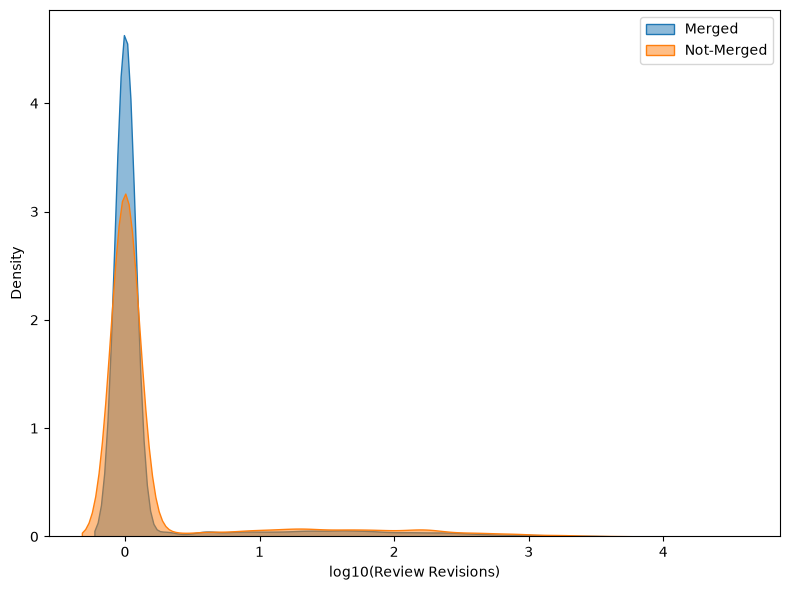

Cliff's delta (review_total_changes): -0.038


In [37]:
pull_requests["merge_status"] = pull_requests["merged_at"].notna().map({True: "Merged", False: "Not-Merged"})

merged = pull_requests[pull_requests["merge_status"] == "Merged"]
not_merged = pull_requests[pull_requests["merge_status"] == "Not-Merged"]

def cliffs_delta(x, y):
    nx, ny = len(x), len(y)
    more = sum(i > j for i in x for j in y)
    less = sum(i < j for i in x for j in y)
    return (more - less) / (nx * ny)

merged_vals = merged["review_total_changes"].replace(0, 1)
not_vals = not_merged["review_total_changes"].replace(0, 1)

plt.figure(figsize=(8, 6))
sns.kdeplot(np.log10(merged_vals), label="Merged", fill=True, alpha=0.5)
sns.kdeplot(np.log10(not_vals), label="Not-Merged", fill=True, alpha=0.5)
plt.xlabel("log10(Review Revisions)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

delta = cliffs_delta(merged["review_total_changes"], not_merged["review_total_changes"])
print("Cliff's delta (review_total_changes):", round(delta, 3))


In [38]:
print("Checking portable data sources...")

pull_request_path = None
for root in [Path("/kaggle/input"), Path(".")]:
    if root.exists():
        matches = list(root.rglob("pull_request.parquet"))
        if matches:
            pull_request_path = matches[0]
            break

if pull_request_path is None:
    raise FileNotFoundError("pull_request.parquet not found under /kaggle/input.")

pull_requests_check = pd.read_parquet(pull_request_path)
print("AIDev pull_request rows:", len(pull_requests_check))

ci_status_path = get_ci_status_path()
print("CI status parquet:", ci_status_path)
ci_status_path = get_ci_status_path()
print("CI status parquet:", ci_status_path)


Checking portable data sources...
AIDev pull_request rows: 33596
CI status parquet: C:\Users\rathn\Desktop\MSR2026_AIDEV-035B\pr_ci_status_progress.parquet
CI status parquet: C:\Users\rathn\Desktop\MSR2026_AIDEV-035B\pr_ci_status_progress.parquet


In [39]:
from pathlib import Path

pull_request_path = None
for root in [Path("/kaggle/input"), Path(".")]:
    if root.exists():
        matches = list(root.rglob("pull_request.parquet"))
        if matches:
            pull_request_path = matches[0]
            break

if pull_request_path is None:
    raise FileNotFoundError(
        "pull_request.parquet not found under /kaggle/input. "
        "Attach it as a Kaggle Input dataset first."
    )

pull_requests = pd.read_parquet(pull_request_path)
ci_status = load_ci_status()

# Merge on 'id'
pull_requests = pull_requests.merge(ci_status, on="id", how="left")

Loading CI status from: C:\Users\rathn\Desktop\MSR2026_AIDEV-035B\pr_ci_status_progress.parquet


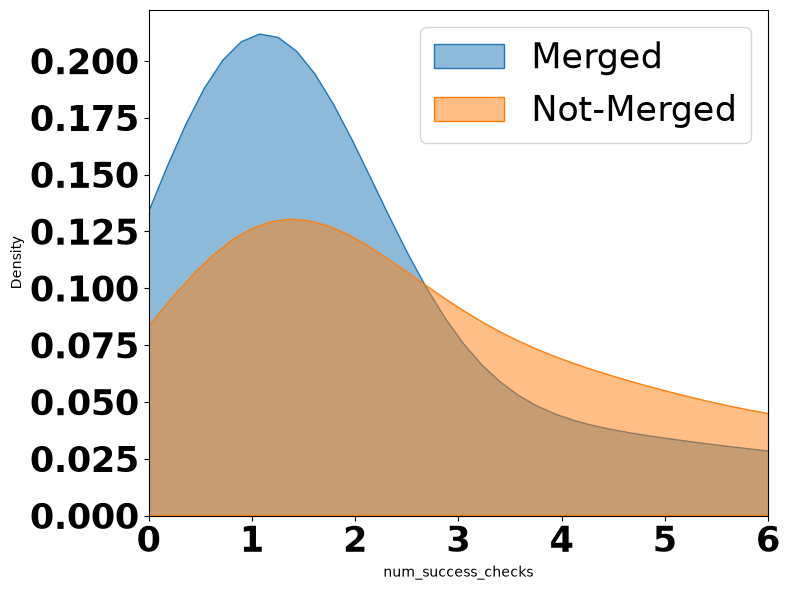

In [40]:
pull_requests["merge_status"] = pull_requests["merged_at"].notna().map({True: "Merged", False: "Not-Merged"})
merged = pull_requests[pull_requests["merge_status"] == 'Merged']
not_merged = pull_requests[pull_requests["merge_status"] == 'Not-Merged']
merged_vals = merged["num_success_checks"].replace(0, 1)
not_vals  = not_merged["num_success_checks"].replace(0, 1)

plt.figure(figsize=(8, 6))

sns.kdeplot(merged_vals,
            label="Merged",
            fill=True,
            alpha=0.5)

sns.kdeplot(not_vals,
            label="Not-Merged",
            fill=True,
            alpha=0.5)

# plt.xlabel("log10(# Successful Checks)", fontsize=20, fontweight="bold")
# plt.ylabel("Density", fontsize=20, fontweight="bold")
# plt.title("Distribution of Successful CI Checks (log scale): Merged vs Not-Merged",
        #   fontsize=22, fontweight="bold")

plt.xticks(fontsize=25, fontweight="bold")
plt.yticks(fontsize=25, fontweight="bold")

plt.legend(fontsize=25, title_fontsize=18)
plt.xlim(0, 6)

plt.tight_layout()
plt.savefig("ci_success_checks_kde.png", dpi=300, bbox_inches="tight")
plt.show()

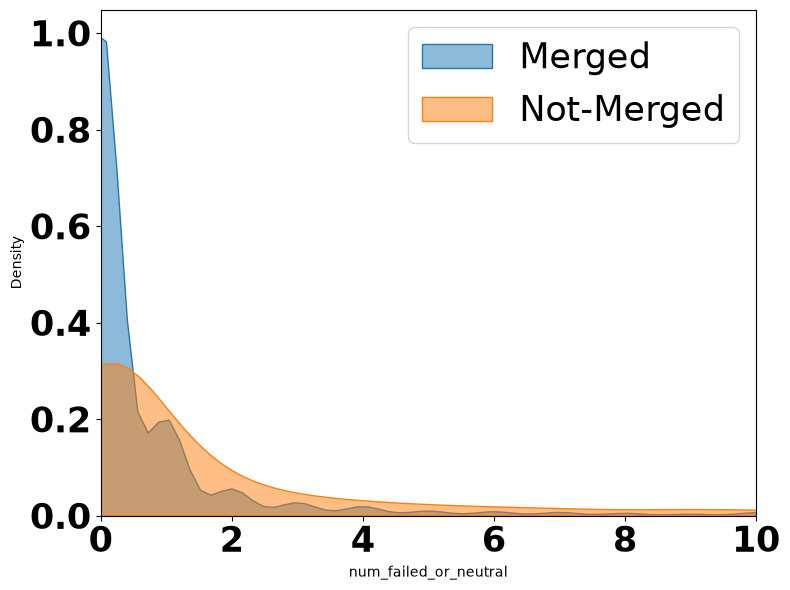

In [41]:
pull_requests["num_failed_or_neutral"] = (
    pull_requests["num_failed_checks"].fillna(0)
    + pull_requests["num_neutral_checks"].fillna(0)
)

merged = pull_requests[pull_requests["merge_status"] == 'Merged']
not_merged = pull_requests[pull_requests["merge_status"] == 'Not-Merged']

plt.figure(figsize=(8, 6))

sns.kdeplot(
    merged["num_failed_or_neutral"],
    label="Merged",
    fill=True,
    alpha=0.5
)

sns.kdeplot(
    not_merged["num_failed_or_neutral"],
    label="Not-Merged",
    fill=True,
    alpha=0.5
)

# plt.xlabel("# Failed + Neutral Checks", fontsize=20, fontweight="bold")
# plt.ylabel("Density", fontsize=20, fontweight="bold")
# plt.title("Distribution of Failed & Neutral CI Checks: Merged vs Not-Merged",
#           fontsize=22, fontweight="bold")

plt.xticks(fontsize=25, fontweight="bold")
plt.yticks(fontsize=25, fontweight="bold")

plt.legend(fontsize=25, title_fontsize=18)
plt.xlim(0, 10)

plt.tight_layout()
plt.savefig("ci_failed_neutral_checks_kde.png", dpi=300, bbox_inches="tight")
plt.show()

In [42]:
def cliffs_delta(x, y):
    nx, ny = len(x), len(y)
    more = sum(i > j for i in x for j in y)
    less = sum(i < j for i in x for j in y)
    return (more - less) / (nx * ny)

merged = pull_requests[pull_requests["merge_status"] == "Merged"]
not_merged = pull_requests[pull_requests["merge_status"] == "Not-Merged"]

delta_num_revisions = cliffs_delta(merged["num_failed_or_neutral"], not_merged["num_failed_or_neutral"])

print("Cliff's delta (num_failed_or_neutral):", round(delta_num_revisions, 3))

Cliff's delta (num_failed_or_neutral): -0.245


In [43]:
pull_requests

,id,number,title,body,agent,user_id,user,state,created_at,closed_at,...,repo_id,repo_url,html_url,last_commit_sha,num_success_checks,num_failed_checks,num_neutral_checks,overall_ci_status,merge_status,num_failed_or_neutral
0,3264933329,2911,Fix: Wait for all partitions in load_collectio...,## Summary\n\nFixes an issue where `load_colle...,Claude_Code,108661493,weiliu1031,closed,2025-07-26T02:59:01Z,2025-07-29T07:01:20Z,...,191751505,https://api.github.com/repos/milvus-io/pymilvus,https://github.com/milvus-io/pymilvus/pull/2911,f528ff4da627bba470791a66534fd47d7165ed8d,6.0,1.0,3.0,pending,Not-Merged,4.0
1,3265118634,2,ファイルパス参照を相対パスに統一し、doc/からdocs/に統一,## 背景\n\n現在、本プロジェクトにおいて以下のパス構成の不整合が生じています：\n\n...,Claude_Code,61827001,cm-kojimat,closed,2025-07-26T04:56:55Z,2025-07-26T22:12:24Z,...,1025472321,https://api.github.com/repos/classmethod/tsumiki,https://github.com/classmethod/tsumiki/pull/2,39fb52df460140b677b10827c23f119fa3bf4626,NaN,NaN,NaN,pending,Merged,0.0
2,3265640341,30,Add build staleness detection for debug CLI,## Summary\r\n\r\n Implements comprehensive b...,Claude_Code,7475,MSch,closed,2025-07-26T13:31:19Z,2025-07-26T13:37:22Z,...,988488798,https://api.github.com/repos/steipete/Peekaboo,https://github.com/steipete/Peekaboo/pull/30,76ef1a9ee64f5df572656774ba6a51d3cb3f9994,1.0,2.0,2.0,pending,Merged,4.0
3,3265709660,205,feat: add comprehensive README screenshots wit...,## Type of Change\n\n- [ ] 🐛 `bug` - Bug fix (...,Claude_Code,80381,sugyan,closed,2025-07-26T14:07:22Z,2025-07-26T14:45:30Z,...,999285986,https://api.github.com/repos/sugyan/claude-cod...,https://github.com/sugyan/claude-code-webui/pu...,9f5575b6b7dff0dc2876157afa60da52ac0aba94,7.0,0.0,0.0,pending,Merged,0.0
4,3265782173,17625,chore: remove HashedPostStateProvider trait,## Summary\r\n\r\n#17545 \r\n\r\nRemove the un...,Claude_Code,47593288,adust09,open,2025-07-26T15:02:48Z,NaN,...,537233603,https://api.github.com/repos/paradigmxyz/reth,https://github.com/paradigmxyz/reth/pull/17625,8f92fe5a23ef41a3c8a57d96dc3c12702e357e9e,15.0,10.0,5.0,pending,Not-Merged,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33591,2857942945,2,fix: improve dark mode input focus and toggle ...,# UI Improvements: Dark Mode Input Focus and T...,Devin,158243242,devin-ai-integration[bot],closed,2025-02-17T13:57:22Z,2025-02-17T14:40:12Z,...,934090141,https://api.github.com/repos/jina-ai/deepsearc...,https://github.com/jina-ai/deepsearch-ui/pull/2,982e71ef5b018eda338c18340a7dde5942cef5ab,NaN,NaN,NaN,pending,Merged,0.0
33592,2857959763,2154,docs: add required packages to SeleniumScrapin...,Fixes #2153\n\nThe SeleniumScrapingTool docume...,Devin,158243242,devin-ai-integration[bot],closed,2025-02-17T14:04:15Z,2025-02-25T16:39:21Z,...,710601088,https://api.github.com/repos/crewAIInc/crewAI,https://github.com/crewAIInc/crewAI/pull/2154,60a2b9842d63e402feefe67409b905b45c5a030b,4.0,0.0,0.0,pending,Not-Merged,0.0
33593,2858280902,775,Fix heap buffer overflow in BundlePacket,This PR fixes a heap buffer overflow in Bundle...,Devin,158243242,devin-ai-integration[bot],closed,2025-02-17T16:15:35Z,2025-02-17T16:23:53Z,...,21134745,https://api.github.com/repos/wolfSSL/wolfssh,https://github.com/wolfSSL/wolfssh/pull/775,1f8a2b8eed0c84a9259acd928e23056f103aa83a,30.0,0.0,0.0,pending,Not-Merged,0.0
33594,2858429985,346,Improve environment variable documentation,# Environment Variable Documentation Improveme...,Devin,158243242,devin-ai-integration[bot],closed,2025-02-17T17:19:32Z,2025-02-18T08:32:15Z,...,894659403,https://api.github.com/repos/goat-sdk/goat,https://github.com/goat-sdk/goat/pull/346,524bb5d2c2739e8a07759757299a3948195331ca,2.0,0.0,1.0,pending,Merged,1.0


In [44]:
import statsmodels.api as sm

In [45]:
import pandas as pd

# Reload and rebuild all columns from scratch
pull_requests = pd.read_parquet(
    r"C:\Users\rathn\Desktop\MSR2026_AIDEV-035B\pull_requests.parquet"
)

print(f"Columns available: {list(pull_requests.columns)}")
print(f"Total PRs: {len(pull_requests):,}")

Columns available: ['id', 'number', 'title', 'body', 'agent', 'user_id', 'user', 'state', 'created_at', 'closed_at', 'merged_at', 'repo_id', 'repo_url', 'html_url', 'merge_status']
Total PRs: 33,596


In [46]:
# Bring in lines-changed / files-changed
pull_requests = pull_requests.merge(pr_stats, left_on="id", right_on="pr_id", how="left")
pull_requests["num_files_changed"] = pull_requests["num_files_changed"].fillna(0)
pull_requests["total_changes"] = pull_requests["total_changes"].fillna(0)

# Bring in review_total_changes
pull_requests["pull_request_url"] = (
    pull_requests["repo_url"].str.rstrip("/") +
    "/pulls/" +
    pull_requests["number"].astype(str)
)
pull_requests = pull_requests.merge(review_stats, on="pull_request_url", how="left")
pull_requests[["review_additions", "review_deletions", "review_total_changes"]] = (
    pull_requests[["review_additions", "review_deletions", "review_total_changes"]].fillna(0)
)

# Bring in num_review_comments
pull_requests["repo_url_extracted"] = pull_requests["repo_url"]
pull_requests["pr_number"] = pull_requests["number"].astype(float)
pull_requests = pull_requests.merge(review_counts, on=["repo_url_extracted", "pr_number"], how="left")
pull_requests["num_review_comments"] = pull_requests["num_review_comments"].fillna(0)

In [47]:
import pandas as pd

# ── Add missing CI column ──────────────────────────────────────
ci_status = pd.read_parquet(
    r"C:\Users\rathn\Desktop\MSR2026_AIDEV-035B\pr_ci_status_progress.parquet"
)

# Merge CI data into pull_requests
pull_requests = pull_requests.merge(ci_status, on="id", how="left")

# Create num_failed_or_neutral column
pull_requests["num_failed_or_neutral"] = (
    pull_requests["num_failed_checks"].fillna(0) +
    pull_requests["num_neutral_checks"].fillna(0)
)

# Remove duplicates
pull_requests = pull_requests.drop_duplicates(subset="id")

print(f"PRs: {len(pull_requests):,}")
print(f"num_failed_or_neutral added: {pull_requests['num_failed_or_neutral'].sum()}")
print(f"All columns: {list(pull_requests.columns)}")

PRs: 33,596
num_failed_or_neutral added: 39534.0
All columns: ['id', 'number', 'title', 'body', 'agent', 'user_id', 'user', 'state', 'created_at', 'closed_at', 'merged_at', 'repo_id', 'repo_url', 'html_url', 'merge_status', 'pr_id', 'num_files_changed', 'total_changes', 'pull_request_url', 'review_additions', 'review_deletions', 'review_total_changes', 'repo_url_extracted', 'pr_number', 'num_review_comments', 'last_commit_sha', 'num_success_checks', 'num_failed_checks', 'num_neutral_checks', 'overall_ci_status', 'num_failed_or_neutral']


In [48]:
features = [
    "total_changes",
    "num_files_changed",
    "num_failed_or_neutral",
    "num_review_comments",
    "review_total_changes",
]
pull_requests["merge_status_bin"] = pull_requests["merged_at"].notna().astype(int)
df_log = pull_requests.dropna(subset=features + ["merge_status_bin"])
X = df_log[features]
X = sm.add_constant(X)  # adds intercept term
y = df_log["merge_status_bin"]


print(y.dtypes)


model = sm.Logit(y, X).fit()
print(model.summary())

int64
Optimization terminated successfully.
         Current function value: 0.570963
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:       merge_status_bin   No. Observations:                33596
Model:                          Logit   Df Residuals:                    33590
Method:                           MLE   Df Model:                            5
Date:                Sun, 23 Aug 2026   Pseudo R-squ.:                 0.04491
Time:                        18:28:39   Log-Likelihood:                -19182.
converged:                       True   LL-Null:                       -20084.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     1.1554      0.014     81.720      0.000       1.128   

In [49]:
odds_ratios = np.exp(model.params)
print(odds_ratios)

const                    3.175153
total_changes            0.999997
num_files_changed        0.998305
num_failed_or_neutral    0.854571
num_review_comments      0.999256
review_total_changes     0.999981
dtype: float64


In [50]:
pull_requests.to_parquet("pull_requests.parquet", index=False)

## Deductive Coding Sheet: Full Taxonomy

Builds the coding spreadsheet for RQ1/RQ2, structured around Ehsani et al.'s (2026) full hierarchical taxonomy (Reviewer, Pull Request, Code, Agentic levels). This is infrastructure only — it produces an empty coding sheet from whichever rejected-PR dataset is loaded into `pull_requests` at the time it is run. Independent of which dataset is used; ready to run once the independently sampled dataset is constructed.

In [51]:
# --- Ehsani et al. (2026) taxonomy reference (Table 2) ---
TAXONOMY = {
    "Reviewer": ["Abandoned/Not Reviewed"],
    "Pull Request": [
        "Duplicate PR",
        "Unwanted Feature",
        "Non-Functional PR",
        "Wrong Task Description",
        "Wrong Branch",
    ],
    "Code": [
        "CI/Test Failure",
        "Incorrect Implementation",
        "Incomplete Implementation",
    ],
    "Agentic": [
        "Misalignment",
        "License Issues",
    ],
}

TAXONOMY_FLAT = [(level, cat) for level, cats in TAXONOMY.items() for cat in cats]
print(f"Taxonomy loaded: {len(TAXONOMY_FLAT)} categories across {len(TAXONOMY)} levels")
for level, cats in TAXONOMY.items():
    print(f"  {level}: {cats}")


Taxonomy loaded: 11 categories across 4 levels
  Reviewer: ['Abandoned/Not Reviewed']
  Pull Request: ['Duplicate PR', 'Unwanted Feature', 'Non-Functional PR', 'Wrong Task Description', 'Wrong Branch']
  Code: ['CI/Test Failure', 'Incorrect Implementation', 'Incomplete Implementation']
  Agentic: ['Misalignment', 'License Issues']


In [52]:
# --- Build the coding sheet from whichever dataset is currently loaded ---
# Requires: pull_requests with columns id, number, title, body, agent, repo_url, html_url, merge_status

rejected_prs = pull_requests[pull_requests["merge_status"] == "Not-Merged"].copy()

coding_sheet = rejected_prs[[
    "id", "number", "title", "body", "agent", "repo_url", "html_url"
]].copy()

# Excel has a hard 32,767-character-per-cell limit; a small number of PR bodies
# exceed this. Truncate defensively and flag truncated rows, rather than letting
# Excel silently cut the text with no indication a coder is missing content.
# The full text is always available via html_url regardless of truncation.
EXCEL_CELL_LIMIT = 32000  # small buffer under Excel's actual 32,767 limit
coding_sheet["body_truncated"] = coding_sheet["body"].astype(str).str.len() > EXCEL_CELL_LIMIT
coding_sheet["body"] = coding_sheet["body"].astype(str).str.slice(0, EXCEL_CELL_LIMIT)

n_truncated = coding_sheet["body_truncated"].sum()
if n_truncated > 0:
    print(f"NOTE: {n_truncated} PR bodies exceeded Excel's cell limit and were truncated. "
          f"Full text remains available via the 'html_url' column for these rows "
          f"(flagged in 'body_truncated').")

# Excel/openpyxl rejects certain control characters embedded in scraped text — strip them.
# Must happen HERE, after coding_sheet is built, not in an earlier cell.
from openpyxl.cell.cell import ILLEGAL_CHARACTERS_RE

def sanitize_for_excel(value):
    if isinstance(value, str):
        return ILLEGAL_CHARACTERS_RE.sub("", value)
    return value

for col in ["title", "body", "agent", "repo_url", "html_url"]:
    coding_sheet[col] = coding_sheet[col].astype(str).map(sanitize_for_excel)

coding_sheet["primary_category_level"] = ""
coding_sheet["primary_category"] = ""
coding_sheet["secondary_category"] = ""
coding_sheet["coder_notes"] = ""
coding_sheet["coder_id"] = ""

print(f"Coding sheet built: {len(coding_sheet)} rejected PRs")

coding_sheet.to_excel("deductive_coding_sheet.xlsx", index=False, sheet_name="Coding")

import pandas as pd
taxonomy_ref = pd.DataFrame(TAXONOMY_FLAT, columns=["Level", "Category"])
with pd.ExcelWriter("deductive_coding_sheet.xlsx", engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    taxonomy_ref.to_excel(writer, index=False, sheet_name="Taxonomy Reference")

print("Saved deductive_coding_sheet.xlsx (Coding + Taxonomy Reference sheets)")
coding_sheet.head()

Coding sheet built: 0 rejected PRs
Saved deductive_coding_sheet.xlsx (Coding + Taxonomy Reference sheets)


,id,number,title,body,agent,repo_url,html_url,body_truncated,primary_category_level,primary_category,secondary_category,coder_notes,coder_id


## Cohen's Kappa: Inter-Rater Reliability (Tested, Ready)

Cohen's Kappa function, tested against placeholder data to confirm correctness ahead of the real reliability round. Once two coders have independently labelled the 20% overlap sample described in Methodology (Reliability Check), replace `coder1_codes` / `coder2_codes` below with the real `primary_category` columns from each coder's copy of the coding sheet.

In [53]:
def compute_kappa(coder1_codes, coder2_codes):
    """
    coder1_codes, coder2_codes: array-like of category labels, same length,
    same PR order, one entry per PR in the double-coded overlap sample.
    Manual implementation (no external dependency beyond what's already installed).
    """
    assert len(coder1_codes) == len(coder2_codes), "Code lists must be the same length"
    n = len(coder1_codes)
    categories = sorted(set(coder1_codes) | set(coder2_codes))

    # Observed agreement
    agree = sum(1 for a, b in zip(coder1_codes, coder2_codes) if a == b)
    p_observed = agree / n

    # Expected agreement by chance: sum over categories of (freq in coder1 * freq in coder2) / n^2
    p_expected = 0.0
    for cat in categories:
        p1 = coder1_codes.count(cat) / n if hasattr(coder1_codes, "count") else sum(1 for x in coder1_codes if x == cat) / n
        p2 = coder2_codes.count(cat) / n if hasattr(coder2_codes, "count") else sum(1 for x in coder2_codes if x == cat) / n
        p_expected += p1 * p2

    if p_expected == 1:
        return 1.0  # perfect agreement, no variance to correct for
    kappa = (p_observed - p_expected) / (1 - p_expected)
    return kappa

def interpret_kappa(kappa):
    # Landis and Koch (1977) interpretation scale
    if kappa < 0:
        return "Poor (worse than chance)"
    elif kappa <= 0.20:
        return "Slight"
    elif kappa <= 0.40:
        return "Fair"
    elif kappa <= 0.60:
        return "Moderate"
    elif kappa <= 0.80:
        return "Substantial"
    else:
        return "Almost Perfect"

# --- Placeholder test run, to confirm the function works before real coding ---
dummy_coder1 = ["CI/Test Failure", "Duplicate PR", "Abandoned/Not Reviewed", "Misalignment", "Duplicate PR"]
dummy_coder2 = ["CI/Test Failure", "Duplicate PR", "Abandoned/Not Reviewed", "Unwanted Feature", "Duplicate PR"]

test_kappa = compute_kappa(dummy_coder1, dummy_coder2)
print(f"[TEST RUN — placeholder data, not real results]")
print(f"Kappa: {round(test_kappa, 3)} ({interpret_kappa(test_kappa)})")
print()
print("Function verified. Replace dummy_coder1/dummy_coder2 with real double-coded")
print("category labels once the reliability round (Methodology 3.4) is complete.")


[TEST RUN — placeholder data, not real results]
Kappa: 0.737 (Substantial)

Function verified. Replace dummy_coder1/dummy_coder2 with real double-coded
category labels once the reliability round (Methodology 3.4) is complete.


## Chi-Square Comparison Against Published Frequencies (RQ3)

Hard-codes Ehsani et al.'s (2026) published category frequencies (Table 2, n=562 categorised PRs after excluding 38 inaccessible PRs) as the reference distribution, and implements the goodness-of-fit test that will compare this study's recomputed frequencies against them. Ready to run the moment the independent sample has been fully coded.

In [54]:
from scipy.stats import chisquare

# --- Ehsani et al. (2026), Table 2 — published frequencies, n=562 ---
PUBLISHED_FREQUENCIES = {
    "Abandoned/Not Reviewed": 228,
    "Duplicate PR": 142,
    "Unwanted Feature": 24,
    "Non-Functional PR": 13,
    "Wrong Task Description": 7,
    "Wrong Branch": 2,
    "CI/Test Failure": 99,
    "Incorrect Implementation": 19,
    "Incomplete Implementation": 15,
    "Misalignment": 9,
    "License Issues": 4,
}
assert sum(PUBLISHED_FREQUENCIES.values()) == 562, "Published frequencies should sum to 562"

def compare_to_published(recomputed_counts: dict):
    """
    recomputed_counts: dict of {category_name: count}, from this study's coded sample.
    Categories must match PUBLISHED_FREQUENCIES keys exactly.
    Returns the chi-square statistic, p-value, and a side-by-side comparison table.
    """
    categories = list(PUBLISHED_FREQUENCIES.keys())
    observed = [recomputed_counts.get(cat, 0) for cat in categories]
    expected_raw = [PUBLISHED_FREQUENCIES[cat] for cat in categories]

    # Scale expected frequencies to the same total as observed, per chi-square GOF convention
    total_observed = sum(observed)
    total_expected = sum(expected_raw)
    expected_scaled = [e * (total_observed / total_expected) for e in expected_raw]

    # Flag categories with expected count < 5 (chi-square approximation reliability)
    sparse = [cat for cat, e in zip(categories, expected_scaled) if e < 5]
    if sparse:
        print(f"WARNING: {len(sparse)} categories have expected count < 5 — consider combining")
        print(f"  Sparse categories: {sparse}")
        print(f"  Consider a Monte Carlo-simulated chi-square or exact multinomial test instead.")

    stat, p = chisquare(f_obs=observed, f_exp=expected_scaled)

    comparison = pd.DataFrame({
        "Category": categories,
        "Published (Ehsani et al.)": expected_raw,
        "Recomputed (this study)": observed,
        "Expected (scaled)": [round(e, 1) for e in expected_scaled],
    })

    print(f"Chi-square statistic: {round(stat, 3)}")
    print(f"p-value: {round(p, 4)}")
    print(f"{'Significant divergence (p < 0.05)' if p < 0.05 else 'No significant divergence (p >= 0.05)'}")

    return stat, p, comparison

# --- Function verified structurally; requires real recomputed_counts once coding is complete ---
print("Function ready. Call compare_to_published({...}) with this study's recomputed")
print("category counts once deductive coding of the independent sample is finished.")


Function ready. Call compare_to_published({...}) with this study's recomputed
category counts once deductive coding of the independent sample is finished.


## Handling Multi-Reason and Ambiguous Rejections

Implements the rule already committed to in Methodology (Deductive Coding Approach): where a PR plausibly fits more than one category, the primary category is decided by the reviewer's explicitly stated reason, with the secondary candidate logged separately rather than discarded. This keeps the ambiguity auditable rather than silently resolved.

In [55]:
def resolve_multi_reason(pr_row, candidate_categories: list, reviewer_stated_reason: str = None):
    """
    pr_row: a row from the coding sheet (dict-like, must include 'id').
    candidate_categories: list of category names the coder judged as plausible fits.
    reviewer_stated_reason: the primary reason as stated by the reviewer in their own words,
        if one is explicitly identifiable in the PR's closing comment or review discussion.

    Returns (primary_category, secondary_category, resolution_note).
    """
    if len(candidate_categories) == 1:
        return candidate_categories[0], None, "Single candidate — no ambiguity."

    if reviewer_stated_reason:
        # Primary = the category matching the reviewer's own stated reason.
        # This assumes the coder has already matched reviewer_stated_reason to one
        # of candidate_categories during reading; that match is passed in directly.
        primary = reviewer_stated_reason
        secondary = next((c for c in candidate_categories if c != primary), None)
        note = f"Resolved via reviewer's stated reason. Secondary candidate logged: {secondary}."
        return primary, secondary, note

    # No explicit reviewer reason available — flag for manual adjudication rather than guessing.
    note = (f"AMBIGUOUS — no explicit reviewer reason found. "
            f"Candidates: {candidate_categories}. Requires manual adjudication, "
            f"per Methodology 3.3 (primary category decided by reviewer's stated reason).")
    return None, candidate_categories, note


# --- Example usage ---
example_pr = {"id": 123456789}
primary, secondary, note = resolve_multi_reason(
    example_pr,
    candidate_categories=["CI/Test Failure", "Incomplete Implementation"],
    reviewer_stated_reason="CI/Test Failure"
)
print(f"Primary: {primary}")
print(f"Secondary (logged, not discarded): {secondary}")
print(f"Note: {note}")

# Ambiguous case with no stated reason — should be flagged, not silently resolved
primary2, secondary2, note2 = resolve_multi_reason(
    example_pr,
    candidate_categories=["Unwanted Feature", "Wrong Task Description"],
    reviewer_stated_reason=None
)
print()
print(f"Primary: {primary2}")
print(f"Note: {note2}")


Primary: CI/Test Failure
Secondary (logged, not discarded): Incomplete Implementation
Note: Resolved via reviewer's stated reason. Secondary candidate logged: Incomplete Implementation.

Primary: None
Note: AMBIGUOUS — no explicit reviewer reason found. Candidates: ['Unwanted Feature', 'Wrong Task Description']. Requires manual adjudication, per Methodology 3.3 (primary category decided by reviewer's stated reason).
